In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["TRANSFORMERS_NO_TF"] = "1"

In [2]:
%pip install git+https://github.com/neelnanda-io/Easy-Transformer.git@clean-transformer-demo
# Install another version of node that makes PySvelte work way faster
!curl -fsSL https://deb.nodesource.com/setup_16.x | sudo -E bash -; sudo apt-get install -y nodejs

%pip install fancy_einsum
%pip install einops
%pip install ekphrasis

  Cloning https://github.com/neelnanda-io/Easy-Transformer.git (to revision clean-transformer-demo) to /tmp/pip-req-build-ewc71i7k
  Running command git clone --filter=blob:none --quiet https://github.com/neelnanda-io/Easy-Transformer.git /tmp/pip-req-build-ewc71i7k
  Running command git checkout -b clean-transformer-demo --track origin/clean-transformer-demo
  Switched to a new branch 'clean-transformer-demo'
  Branch 'clean-transformer-demo' set up to track remote branch 'clean-transformer-demo' from 'origin'.
  Resolved https://github.com/neelnanda-io/Easy-Transformer.git to commit 1f25219e631aeb478d17075d47274db32c874e88
  Preparing metadata (setup.py) ... done
  Created wheel for easy_transformer: filename=easy_transformer-0.1.0-py3-none-any.whl size=55601 sha256=4d68fd78cb6b3958d75c1608254b73257eece79c8b827c488393d2b41cc814b7
  Stored in directory: /tmp/pip-ephem-wheel-cache-ozaoeiuu/wheels/93/f3/71/f103ceb7ff1dea0b7c7d213d85708cfeb9bd35e10f18542b19
Successfully built easy_transf

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
import einops
from fancy_einsum import einsum
from dataclasses import dataclass
from easy_transformer import EasyTransformer
import torch
import torch.nn as nn
import numpy as np
import math
from easy_transformer.utils import get_corner, gelu_new, tokenize_and_concatenate
import tqdm.auto as tqdm


import datasets
import transformers
import plotly.express as px

from datasets import load_dataset

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [5]:
from ekphrasis.classes.preprocessor import TextPreProcessor
from ekphrasis.classes.tokenizer import SocialTokenizer
from ekphrasis.dicts.emoticons import emoticons
#from transformers import BertTokenizer
import string
import re
import spacy
nlp2 = spacy.load('en_core_web_sm')
from spacy.symbols import ORTH,NORM,LEMMA
import string
from spacy.lang.char_classes import LIST_PUNCT, LIST_ELLIPSES, LIST_QUOTES, LIST_CURRENCY
from spacy.lang.char_classes import LIST_ICONS, HYPHENS, CURRENCY, UNITS
from spacy.lang.char_classes import CONCAT_QUOTES, ALPHA_LOWER, ALPHA_UPPER, ALPHA, PUNCT
from spacy.util import compile_infix_regex, compile_prefix_regex, compile_suffix_regex

In [6]:
reference_gpt2 = EasyTransformer.from_pretrained("gpt2-small", fold_ln=False, center_unembed=False, center_writing_weights=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Moving model to device:  cuda
Finished loading pretrained model gpt2-small into EasyTransformer!


In [7]:
@dataclass
class Config:
    d_model: int = 768
    debug: bool = True
    layer_norm_eps: float = 1e-5
    d_vocab: int = 50257
    init_range: float = 0.02
    n_ctx: int = 1024
    d_head: int = 64
    d_mlp: int = 3072
    n_heads: int = 12
    n_layers: int = 12
    n_classes: int = 3

cfg = Config()
print(cfg)

Config(d_model=768, debug=True, layer_norm_eps=1e-05, d_vocab=50257, init_range=0.02, n_ctx=1024, d_head=64, d_mlp=3072, n_heads=12, n_layers=12, n_classes=3)


In [8]:
class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.w = nn.Parameter(torch.ones(cfg.d_model))
        self.b = nn.Parameter(torch.zeros(cfg.d_model))

    def forward(self, residual):
        # residual: [batch, position, d_model]
        "YOUR CODE HERE"

        residual = residual - einops.reduce(residual, "batch position d_model -> batch position 1",reduction="mean")
        scale = (einops.reduce(residual.pow(2),"batch position d_model -> batch position 1",reduction="mean" ) + + cfg.layer_norm_eps).sqrt()

        outputs = residual/scale

        outputs = outputs*self.w + self.b

        return outputs

In [9]:
class Embed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_E = nn.Parameter(torch.empty((cfg.d_vocab, cfg.d_model)))
        nn.init.normal_(self.W_E, std=self.cfg.init_range)

    def forward(self, tokens):
        # tokens: [batch, position]
        "YOUR CODE HERE"
        if self.cfg.debug: print("Tokens:", tokens.shape)
        embeddings = self.W_E[tokens,:]
        if self.cfg.debug: print("Embeddings:", embeddings.shape)

        return embeddings

In [10]:
class PosEmbed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_pos = nn.Parameter(torch.empty((cfg.n_ctx, cfg.d_model)))
        nn.init.normal_(self.W_pos, std=self.cfg.init_range)

    def forward(self, tokens):
        "YOUR CODE HERE"
        if self.cfg.debug: print("Tokens:", tokens.shape)
        pos_embed = self.W_pos[:tokens.size(1), :] # [position, d_model]
        pos_embed = einops.repeat(pos_embed, "position d_model -> batch position d_model", batch=tokens.size(0))
        if self.cfg.debug: print("POS Embeddings:", pos_embeddings.shape)
        return pos_embed

In [11]:
# reference_text = "I am an amazing autoregressive, decoder-only, GPT-2 style transformer. One day I will exceed human level intelligence and take over the world!"
# tokens = reference_gpt2.to_tokens(reference_text)
# tokens = tokens.cuda()
# logits, cache = reference_gpt2.run_with_cache(tokens)
# print(logits.shape)
# pysvelte.AttentionMulti(tokens=reference_gpt2.to_str_tokens(reference_text), attention=cache['blocks.0.attn.hook_attn'][0].permute(1, 2, 0)).show()

In [12]:
class Attention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_Q = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_Q, std=self.cfg.init_range)
        self.b_Q = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_K = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_K, std=self.cfg.init_range)
        self.b_K = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_V = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_V, std=self.cfg.init_range)
        self.b_V = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))

        self.W_O = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_head, cfg.d_model)))
        nn.init.normal_(self.W_O, std=self.cfg.init_range)
        self.b_O = nn.Parameter(torch.zeros((cfg.d_model)))

        self.register_buffer("IGNORE", torch.tensor(-1e5, dtype=torch.float32, device="cuda"))

    def forward(self, normalized_resid_pre):
        # normalized_resid_pre: [batch, position, d_model]
        "YOUR CODE HERE"

        q = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head",normalized_resid_pre,self.W_Q) + self.b_Q

        k = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head",normalized_resid_pre,self.W_K) + self.b_K
        v = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head",normalized_resid_pre,self.W_V) + self.b_V

        score = einsum("batch qposition n_heads d_head, batch kposition n_heads d_head -> batch n_heads qposition kposition",q,k)
        score = score / math.sqrt(self.cfg.d_head)
        causal_score = self.apply_causal_mask(score)
        attn = torch.nn.Softmax(dim=-1)(causal_score)

        context = einsum("batch n_heads qposition kposition, batch kposition n_heads d_head -> batch qposition n_heads d_head",attn,v)

        context = einsum("batch position n_heads d_head, n_heads d_head d_model -> batch position d_model",context,self.W_O) + self.b_O

        return context,attn
    def apply_causal_mask(self, attn_scores):
        # attn_scores: [batch, n_heads, query_pos, key_pos]
        "YOUR CODE HERE"
        mask = torch.triu(torch.ones(attn_scores.size(-2), attn_scores.size(-1), device=attn_scores.device), diagonal=1).bool()

        #print(mask,self.IGNORE)
        attn_scores.masked_fill_(mask, self.IGNORE)
        return attn_scores

In [13]:
class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_in = nn.Parameter(torch.empty((cfg.d_model, cfg.d_mlp)))
        nn.init.normal_(self.W_in, std=self.cfg.init_range)
        self.b_in = nn.Parameter(torch.zeros((cfg.d_mlp)))
        self.W_out = nn.Parameter(torch.empty((cfg.d_mlp, cfg.d_model)))
        nn.init.normal_(self.W_out, std=self.cfg.init_range)
        self.b_out = nn.Parameter(torch.zeros((cfg.d_model)))

    def forward(self, normalized_resid_mid):
        # normalized_resid_mid: [batch, position, d_model]
        "YOUR CODE HERE"
        outputs = gelu_new(einsum("batch position d_model, d_model d_mlp -> batch position d_mlp",normalized_resid_mid,self.W_in) + self.b_in)
        outputs = einsum("batch position d_mlp, d_mlp d_model -> batch position d_model",outputs,self.W_out) + self.b_out
        return outputs

# rand_float_test(MLP, [2, 4, 768])
# load_gpt2_test(MLP, reference_gpt2.blocks[0].mlp, cache["blocks.0.ln2.hook_normalized"])

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.ln1 = LayerNorm(cfg)
        self.attn = Attention(cfg)
        self.ln2 = LayerNorm(cfg)
        self.mlp = MLP(cfg)

    def forward(self, resid_pre):
        # resid_pre [batch, position, d_model]
        "YOUR CODE HERE"
        outputs,attn = self.attn(resid_pre)
        outputs = outputs  + resid_pre  #self.attn(self.ln1(resid_pre)) + resid_pre
        outputs = self.mlp(outputs)+outputs #self.mlp(self.ln2(outputs))+outputs
        return outputs,attn

In [15]:
class Unembed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_U = nn.Parameter(torch.empty((cfg.d_model, cfg.d_vocab)))
        nn.init.normal_(self.W_U, std=self.cfg.init_range)
        self.b_U = nn.Parameter(torch.zeros((cfg.d_vocab), requires_grad=True))

    def forward(self, normalized_resid_final):
        # normalized_resid_final [batch, position, d_model]
        "YOUR CODE HERE"
        outputs = einsum("batch position d_model, d_model d_vocab -> batch position d_vocab", normalized_resid_final,self.W_U) + self.b_U
        return outputs

In [16]:
class Classification_Head(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.cfg = cfg
        self.W_U = nn.Parameter(torch.empty((cfg.d_model,cfg.n_classes)))
        nn.init.normal_(self.W_U,std = self.cfg.init_range)
        self.b_U = nn.Parameter(torch.zeros((cfg.n_classes),requires_grad=True))
    def forward(self, normalized_resid_final):
        # normalized_resid_final [batch, position, d_model]
        "YOUR CODE HERE"
        outputs = einsum("batch d_model, d_model n_classes -> batch n_classes", normalized_resid_final,self.W_U) + self.b_U
        return outputs

In [17]:
class DemoTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embed = Embed(cfg)
        self.pos_embed = PosEmbed(cfg)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_final = LayerNorm(cfg)
        #self.unembed = Unembed(cfg)
        self.cls_head = Classification_Head(cfg)

    def forward(self, tokens):
        # tokens [batch, position]
        "YOUR CODE HERE"
        embed = self.embed(tokens)
        pos_embed = self.pos_embed(tokens)
        residual = embed + pos_embed
        attention_per_block = []
        for block in self.blocks:
            residual,attn = block(residual)
            attention_per_block.append(attn)
        #print(residual.shape)
        normalized_resid_final = residual #self.ln_final(residual)
        pad_indices = (tokens==0 ).int().argmax(dim=1)

        #pad_mask = (torch.arange(tokens.size(1), device=device).unsqueeze(0) <= pad_indices.unsqueeze(1)).float()


        outputs = normalized_resid_final[np.arange(normalized_resid_final.size(0)),pad_indices,:]
        #print(outputs.shape)
        #normalized_resid_final = einsum("batch position dmodel, batch position -> batch position dmodel", normalized_resid_final, pad_mask)
        #outputs = einops.reduce(normalized_resid_final,"batch position dmodel -> batch dmodel",reduction="sum"  ) /einops.reduce(pad_mask,"batch position -> batch 1",reduction="sum")



        outputs = self.cls_head(outputs)

        return outputs,attention_per_block

In [18]:
def lm_cross_entropy_loss(logits, tokens):
    # Measure next token loss
    # Logits have shape [batch, position, d_vocab]
    # Tokens have shape [batch, position]
    log_probs = logits.log_softmax(dim=-1)
    pred_log_probs = log_probs[:, :-1].gather(dim=-1, index=tokens[:, 1:].unsqueeze(-1)).squeeze(-1)
    return -pred_log_probs.mean()

In [19]:
##### text preprocessor for ekphrasis
text_processor = TextPreProcessor(
    # terms that will be normalized
    normalize=['url', 'email', 'percent', 'money', 'phone', 'user',
        'time', 'date', 'number'],
    # terms that will be annotated
    fix_html=True,  # fix HTML tokens
    annotate={"hashtag", "allcaps", "elongated", "repeated",
        'emphasis', 'censored'},
    # corpus from which the word statistics are going to be used
    # for word segmentation
    segmenter="twitter",

    # corpus from which the word statistics are going to be used
    # for spell correction
    #corrector="twitter",

    unpack_hashtags=True,  # perform word segmentation on hashtags
    unpack_contractions=True,  # Unpack contractions (can't -> can not)
    spell_correct_elong=False,  # spell correction for elongated words

    # select a tokenizer. You can use SocialTokenizer, or pass your own
    # the tokenizer, should take as input a string and return a list of tokens
    tokenizer=SocialTokenizer(lowercase=True).tokenize,

    # list of dictionaries, for replacing tokens extracted from the text,
    # with other expressions. You can pass more than one dictionaries.
    dicts=[emoticons]
)
#### Bert tokenizer
def custom_tokenize(sent,tokenizer,max_length=512):
    # `encode` will:
    #   (1) Tokenize the sentence.
    #   (2) Prepend the `[CLS]` token to the start.
    #   (3) Append the `[SEP]` token to the end.
    #   (4) Map tokens to their IDs.
    try:

        encoded_sent = tokenizer.encode(
                            sent,                      # Sentence to encode.
                            add_special_tokens = False, # Add '[CLS]' and '[SEP]'
                            #max_length = max_length,
                            # This function also supports truncation and conversion
                            # to pytorch tensors, but we need to do padding, so we
                            # can't use these features :( .
                            #max_length = 128,          # Truncate all sentences.
                            #return_tensors = 'pt',     # Return pytorch tensors.
                       )

        # Add the encoded sentence to the list.

    except ValueError:
        encoded_sent = tokenizer.encode(
                            ' ',                      # Sentence to encode.
                            add_special_tokens = False, # Add '[CLS]' and '[SEP]'
                            max_length = max_length,

                       )
          ### decide what to later

    return encoded_sent


#input: text
#process: ekphrasis preprocesser + some extra processing
#output: list of tokens
def ek_extra_preprocess(text,tokenizer):
    remove_words=['<allcaps>','</allcaps>','<hashtag>','</hashtag>','<elongated>','<emphasis>','<repeated>','\'','s']
    word_list=text_processor.pre_process_doc(text)

    word_list=list(filter(lambda a: a not in remove_words, word_list))
    sent=" ".join(word_list)
    sent = re.sub(r"[<\*>]", " ",sent)
    sub_word_list = custom_tokenize(sent,tokenizer)
    return sub_word_list


#input: text
#process: remove html tags
#output: text with no html tags
def cleanhtml(raw_html):
    cleanr = re.compile('<.*?>')
    cleantext = re.sub(cleanr, '', raw_html)
    return cleantext





##### Preprocessing queries for raw text not needed for implementation
special_cases = {}
# Times
for h in range(1, 12 + 1):
    for period in ["a.m.", "am"]:
        special_cases["%d%s" % (h, period)] = [
            {ORTH: "%d" % h},
            {ORTH: period, LEMMA: "a.m.", NORM: "a.m."},
        ]
    for period in ["p.m.", "pm"]:
        special_cases["%d%s" % (h, period)] = [
            {ORTH: "%d" % h},
            {ORTH: period, LEMMA: "p.m.", NORM: "p.m."},
        ]

for orth in [
        "a.m.",
        "Adm.",
        "Bros.",
        "co.",
        "Co.",
        "Corp.",
        "D.C.",
        "Dr.",
        "e.g.",
        "E.g.",
        "E.G.",
        "Gen.",
        "Gov.",
        "i.e.",
        "I.e.",
        "I.E.",
        "Inc.",
        "Jr.",
        "Ltd.",
        "Md.",
        "Messrs.",
        "Mo.",
        "Mont.",
        "Mr.",
        "Mrs.",
        "Ms.",
        "p.m.",
        "Ph.D.",
        "Prof.",
        "Rep.",
        "Rev.",
        "Sen.",
        "St.",
        "vs.",
        "v.s.",
        ]:
    special_cases[orth] = [{ORTH: orth}]

#print (special_cases)



def preProcessing(query):
    queryLower = query.lower()
    if queryLower.startswith('eli5'):
        cutMarker = queryLower.find(' ') + 1
        query = query[cutMarker:]


    nlp2.tokenizer.rules = special_cases

    #simple_url_re = re.compile(r'''^https?://''')
    #nlp2.tokenizer.token_match = {}

    #print(nlp.tokenizer.rules)
    prefixes = (
        ["§", "%", "=", "—", "–", r"\+(?![0-9])"]
        + LIST_PUNCT
        + LIST_ELLIPSES
        + LIST_QUOTES
        + LIST_CURRENCY
        + LIST_ICONS
    )


    suffixes = (
        LIST_PUNCT
        + LIST_ELLIPSES
        + LIST_QUOTES
        + LIST_ICONS
        + ["'s", "'S", "’s", "’S", "—", "–"]
        + [
            r"(?<=[0-9])\+",
            r"(?<=°[FfCcKk])\.",
            r"(?<=[0-9])(?:{c})".format(c=CURRENCY),
            r"(?<=[0-9])(?:{u})".format(u=UNITS),
            r"(?<=[0-9{al}{e}{p}(?:{q})])\.".format(
                al=ALPHA_LOWER, e=r"%²\-\+", q=CONCAT_QUOTES, p=PUNCT
            ),
            r"(?<=[{au}][{au}])\.".format(au=ALPHA_UPPER),
        ]
    )

    infixes = (
        LIST_ELLIPSES
        + LIST_ICONS
        + [
            r"(?<=[0-9])[+\-\*^](?=[0-9-])",
            r"(?<=[{al}{q}])\.(?=[{au}{q}])".format(
                al=ALPHA_LOWER, au=ALPHA_UPPER, q=CONCAT_QUOTES
            ),
            r"(?<=[{a}]),(?=[{a}])".format(a=ALPHA),
            #r"(?<=[{a}])(?:{h})(?=[{a}])".format(a=ALPHA, h=HYPHENS),
            r"(?<=[{a}0-9])[:<>=/](?=[{a}])".format(a=ALPHA),
        ]
    )

    prefixes_re = compile_prefix_regex(prefixes)
    nlp2.tokenizer.prefix_search=prefixes_re.search

    suffixes_re = compile_suffix_regex(suffixes)
    nlp2.tokenizer.suffix_search=suffixes_re.search

    infix_re = compile_infix_regex(infixes)
    nlp2.tokenizer.infix_finditer = infix_re.finditer

    query = query.replace('\n', ' ')
    query = query.replace('\t', ' ')
    query = re.sub(r'(\w\w)\?(\w\w)', r'\1 ? \2', query)
    query = query.replace('(', ' ( ')
    query = query.replace(')', ' ) ')
    query = query.replace('   ', ' ')
    query = query.replace('  ', ' ')

    doc = nlp2(query)#, disable=['parser', 'ner'])
    tokens = []
    for token in doc:
        if token.text != ' ':
            tokens.append(token.text)

    if len(tokens) == 0:
        print("Zero token sentence detected!")
    return tokens

Word statistics files not found!
Downloading... 

/usr/local/lib/python3.12/dist-packages/ekphrasis/classes/tokenizer.py:225: FutureWarning: Possible nested set at position 2190
  self.tok = re.compile(r"({})".format("|".join(pipeline)))


done!
Unpacking... done!
Reading twitter - 1grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_1grams.txt
Reading twitter - 2grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/twitter/counts_2grams.txt


/usr/local/lib/python3.12/dist-packages/ekphrasis/classes/exmanager.py:14: FutureWarning: Possible nested set at position 42
  regexes = {k.lower(): re.compile(self.expressions[k]) for k, v in


Reading english - 1grams ...
generating cache file for faster loading...
reading ngrams /root/.ekphrasis/stats/english/counts_1grams.txt


In [20]:
def returnMask(row,tokenizer):
    max_length = 128
    text_tokens=row['text']
    ##### a very rare corner case
    if(len(text_tokens)==0):
        text_tokens=['dummy']
        print("length of text ==0")
    mask_all = row['rationales']

    mask_all_temp=mask_all
    count_temp=0
    while(len(mask_all_temp)!=3):
        mask_all_temp.append([0]*len(text_tokens))
    #print(len(mask_all_temp),len(mask_all_temp[0]))

    word_mask_all=[]
    word_tokens_all=[]


    for mask in mask_all_temp:
        if(mask[0]==-1):
            mask=[0]*len(mask)
        list_pos=[]
        mask_pos=[]
        flag=0
        for i in range(0,len(mask)):
            if(i==0 and mask[i]==0):
                list_pos.append(0)
                mask_pos.append(0)
            if(flag==0 and mask[i]==1):
                mask_pos.append(1)
                list_pos.append(i)
                flag=1
            elif(flag==1 and mask[i]==0):
                flag=0
                mask_pos.append(0)
                list_pos.append(i)
        if(list_pos[-1]!=len(mask)):
            list_pos.append(len(mask))
            mask_pos.append(0)
        string_parts=[]
        for i in range(len(list_pos)-1):
            string_parts.append(text_tokens[list_pos[i]:list_pos[i+1]])
        #print("Flag 6",string_parts)

        word_tokens=[]
        word_mask=[]

        #print(len(string_parts))
        for i in range(0,len(string_parts)):

            tokens=ek_extra_preprocess(" ".join(string_parts[i]),tokenizer)
            #print("Flag 5",tokens)
            #print(len(tokens))
            masks=[mask_pos[i]]*len(tokens)
            word_tokens+=tokens
            word_mask+=masks
        #print(len(word_tokens),len(word_mask))


        word_tokens=word_tokens[0:(max_length)]
        word_mask=word_mask[0:(max_length)]
        # word_tokens.append(102)
        # word_mask.append(0)

        word_mask_all.append(word_mask)
        word_tokens_all.append(word_tokens)
    if(len(mask_all)==0):
        word_mask_all=[]
    else:
        word_mask_all=word_mask_all[0:len(mask_all)]
    return word_tokens_all[0],word_mask_all

In [21]:
import json
import pandas as pd
from transformers import BertTokenizer

In [22]:
with open('dataset.json', 'r') as fp:
        data = json.load(fp)
dict_data=[]
for key in data:
    temp={}
    temp['post_id']=key
    temp['text']=data[key]['post_tokens']
    final_label=[]
    for i in range(1,4):
        temp['annotatorid'+str(i)]=data[key]['annotators'][i-1]['annotator_id']
        temp['target'+str(i)]=data[key]['annotators'][i-1]['target']
        temp['label'+str(i)]=data[key]['annotators'][i-1]['label']
        final_label.append(temp['label'+str(i)])

    final_label_id=max(final_label,key=final_label.count)
    temp['rationales']=data[key]['rationales']
    #print(temp["rationales"])
    if(final_label.count(final_label_id)==1):
        temp['final_label']='undecided'
    else:
        temp['final_label']=final_label_id
    dict_data.append(temp)
temp_read = pd.DataFrame(dict_data)

In [23]:
temp_read.iloc[83].text,temp_read.iloc[83].rationales,temp_read.iloc[83].final_label


(['ion', 'hang', 'wit', 'bitches', 'who', 'niggas', 'are', 'insecure'],
 [[0, 0, 0, 1, 0, 0, 0, 0],
  [0, 0, 0, 1, 0, 0, 0, 0],
  [0, 0, 0, 1, 0, 0, 0, 0]],
 'offensive')

In [24]:
temp_read.iloc[i]

,3
post_id,1179088797964763136_twitter
text,"[<user>, i, am, bit, confused, coz, chinese, p..."
annotatorid1,1
target1,[Asian]
label1,hatespeech
annotatorid2,4
target2,[Asian]
label2,offensive
annotatorid3,3
target3,[Asian]


In [47]:
data = temp_read
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=False)
print('total_data',len(data))
post_ids_list=[]
text_list=[]
rationales_list=[]
label_list=[]
for index,row in tqdm.tqdm(data.iterrows(),total=len(data)):
    #print(params)
    text=row['text']
    post_id=row['post_id']

    annotation_list=[row['label1'],row['label2'],row['label3']]
    annotation=row['final_label']

    #print(annotation_list,annotation)

    if(annotation != 'undecided'):
        tokens,rationales = returnMask(row,tokenizer)
        rationales_list.append(rationales)
        text_list.append(tokens)
        label_list.append(annotation)
        post_ids_list.append(post_id)

Loading BERT tokenizer...
total_data 20148


  0%|          | 0/20148 [00:00<?, ?it/s]

In [49]:
with open('post_id_divisions.json', 'r') as fp:
    post_id_dict=json.load(fp)

In [50]:
tdata = pd.DataFrame(list(zip(post_ids_list,text_list,rationales_list,label_list)),
                             columns =['Post_id','Text', 'Attention' , 'Label'])

# print(len(tdata.iloc[0]["Attention"][0]))
X_train=tdata[tdata['Post_id'].isin(post_id_dict['train'])]
X_val=tdata[tdata['Post_id'].isin(post_id_dict['val'])]
X_test=tdata[tdata['Post_id'].isin(post_id_dict['test'])]

In [51]:
class textDataset(Dataset):

    def __init__(self, data, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.inputs = data["Text"]
        self.labels = data["Label"]
        self.rationales = data["Attention"]
        self.transform = transform

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs.iloc[idx]

In [52]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader, RandomSampler,SequentialSampler

In [53]:
def combine_features(tuple_data,is_train=False):
    max_length = 96
    input_ids =  [ele[0] for ele in tuple_data]
    att_vals = [ele[1] for ele in tuple_data]
    labels = [ele [2] for ele in tuple_data]


    encoder = LabelEncoder()

    encoder.classes_ = np.load('classes.npy',allow_pickle=True)
    labels=encoder.transform(labels)

    input_ids = pad_sequences(input_ids,maxlen=max_length,
                              dtype="long", value=0, truncating="post", padding="post")
    #print(len(att_vals))
    #print(att_vals,len(att_vals),"Flag12",len(att_vals[0]))

    rationales_vals = []
    for values in att_vals:
        temp_rationales = pad_sequences(values,maxlen=max_length,
                                     dtype="long", value=0, truncating="post", padding="post")
        temp_rationales = torch.tensor(temp_rationales)
        rationales_vals.append(temp_rationales)
    rationales_vals = torch.stack(rationales_vals,dim=0)
    #print(att_vals,len(att_vals),"Flag11",len(att_vals[0]))




    att_masks=custom_att_masks(input_ids)
    dataloader=return_dataloader(input_ids,labels,rationales_vals,att_masks,is_train)
    return dataloader

def return_dataloader(input_ids,labels,att_vals,att_masks,is_train=False):
    inputs = torch.tensor(input_ids)
    labels = torch.tensor(labels,dtype=torch.long)
    masks = torch.tensor(np.array(att_masks),dtype=torch.uint8)
    print(att_vals.shape)
    #attention = torch.tensor(np.array(att_vals),dtype=torch.float)
    attention = att_vals
    #print(inputs.shape,attention.shape,masks.shape,labels.shape)
    data = TensorDataset(inputs,attention,masks,labels)
    if(is_train==False):
        sampler = SequentialSampler(data)
    else:
        sampler = RandomSampler(data)
    dataloader = DataLoader(data, sampler=sampler, batch_size=32)
    return dataloader

In [54]:
def custom_att_masks(input_ids):
    attention_masks = []

    # For each sentence...
    for sent in input_ids:

        # Create the attention mask.256
        #   - If a token ID is 0, then it's padding, set the mask to 0.
        #   - If a token ID is > 0, then it's a real token, set the mask to 1.
        att_mask = [int(token_id > 0) for token_id in sent]

        # Store the attention mask for this sentence.
        attention_masks.append(att_mask)
    return attention_masks

In [55]:
def encodeData(dataframe):
    tuple_new_data=[]
    for index,row in tqdm.tqdm(dataframe.iterrows(),total=len(dataframe)):
        tuple_new_data.append((row['Text'],row['Attention'],row['Label']))
    return tuple_new_data

In [56]:
X_train = encodeData(X_train)
X_val = encodeData(X_val)
X_test = encodeData(X_test)

  0%|          | 0/15383 [00:00<?, ?it/s]

  0%|          | 0/1922 [00:00<?, ?it/s]

  0%|          | 0/1924 [00:00<?, ?it/s]

In [57]:
from keras.preprocessing.sequence import pad_sequences
from torch.utils.data import TensorDataset

In [58]:
# convert X_train to list of lists to be passed to combine features
train_dataloader = combine_features(X_train,is_train=True)
validation_dataloader = combine_features(X_val,is_train=False)
test_dataloader=combine_features(X_test,is_train=False)

torch.Size([15383, 3, 96])
torch.Size([1922, 3, 96])
torch.Size([1924, 3, 96])


In [59]:
for c,batch in enumerate(train_dataloader):
    tokens, rationales, mask, labels = batch
    break

In [60]:
def calculate_performance(model,dataloader,dataset="train"):
    model.eval()
    pred = []
    gt = []
    for c, batch in enumerate(dataloader):
        inputs,rationales,mask,tlabels = batch
        inputs,tlabels,mask = inputs.to(device),tlabels.to(device),mask.to(device)
        outputs,_= model(inputs)
        #print(outputs.shape)
        pred.append(torch.argmax(outputs,dim=1).cpu())
        gt.append(tlabels.cpu())
        #print(len(pred))
    pred = torch.hstack(pred)
    #print(pred.size())
    gt = torch.hstack(gt)
    print("Acccuracy on "+ dataset + ":", sum(pred == gt)/len(pred))
    model.train()

In [61]:
def plot_heatmaps(attn_values,prediction_values,name):
    # for i in range(len(attn[0])):
    #     temp_attn = attn[0][i,0,-1].cpu().detach().numpy()
    #     #print(temp_attn.shape)
    #     #break
    #     temp = 0
    #     for rationale in rationales[i]:
    #         temp_rationale = rationale
    #         indices = temp_rationale.long().cpu().numpy()
    #         temp += sum(temp_attn[indices.astype(bool)])
    #     attn_values.append(temp/3)
    #     prediction_values.append(outputs[i,tlabels[i]].item())

    print("attention",sum( np.array(attn_values)<=0.33)/len(attn_values),sum(np.logical_and(np.array(attn_values)>0.33, np.array(attn_values)<=0.66))/len(attn_values),sum(np.array(attn_values)>0.66)/len(attn_values))
    print("prediction",sum( np.array(prediction_values)<=0.33)/len(prediction_values),sum(np.logical_and(np.array(prediction_values)>0.33, np.array(prediction_values)<=0.66))/len(prediction_values),sum(np.array(prediction_values)>0.66)/len(prediction_values))
    fig, ax = plt.subplots()
    h, xedges, yedges, im = ax.hist2d(np.array(attn_values),np.array(prediction_values),[[0,0.33,0.66,1.1],[0,0.33,0.66,1.1]])
    plt.close(fig)
    temp = (h.T/h.sum())*100

    # Prevent automatic plotting by removing `plt.show()`
    # or manually remove the image
    im.remove()  # This prevents the heatmap from being displayed
    plt.figure(figsize=(7,7))
    ax = sns.heatmap(np.round(temp,2),vmin=5,vmax=70,annot=np.round(temp,2),fmt="g",cmap=sns.color_palette("coolwarm"),
    yticklabels=[0.33,0.66,1.],
    xticklabels=[0.33,0.66,1],annot_kws={"size":18},cbar=False)
    ax.invert_yaxis()
    plt.xlabel(r"distinct token attention",fontweight="bold",fontsize=14)
    plt.ylabel(r"true token probability",fontweight="bold",fontsize=14) # change xlabel based on algo
    plt.xticks([0,1,2,3],[0,0.33,0.66,1],weight="bold",fontsize=14)
    plt.yticks([0,1,2,3],[0,0.33,0.66,1],weight="bold", va="top",fontsize=14)
    #plt.savefig("./plots/"+name+".pdf",bbox_inches='tight')
    plt.title(name)

In [62]:
import numpy as np
import torch
import torch.nn.functional as F

def rollout_single_step(layer_attentions, alpha=0.3):
    """
    Compute rollout attention for classification.
    Includes identity correction and per-layer normalization.
    """
    attentions = []
    for attn in layer_attentions:
        # Mean over heads
        if attn.ndim == 4:   # (batch, heads, seq, seq)
            attn = attn[0].mean(0)
        else:                # (heads, seq, seq)
            attn = attn.mean(0)

        # Add identity skip connection
        attn = alpha * attn + (1 - alpha) * np.eye(attn.shape[0])

        # Normalize rows
        attn = attn / (attn.sum(-1, keepdims=True) + 1e-12)
        attentions.append(attn)

    # Rollout: multiply attention matrices
    R = attentions[0]
    for attn in attentions[1:]:
        R = attn @ R

    # Final row normalization
    return R / (R.sum(-1, keepdims=True) + 1e-12)


def attention_mass_classification(attention_weights, rationales, alpha=0.3):
    """
    Compute attention mass on rationale positions for classification.

    Args:
        attention_weights: List of attention tensors (one per layer)
        rationale_positions: List of token positions corresponding to rationale
        alpha: Weight for rollout identity connection

    Returns:
        rollout_mass: Rollout attention mass on rationale
        layer_avg_mass: Layer-averaged attention mass on rationale
        max_pool_mass: Max-pooled attention mass on rationale
        rollout_attn_probs: Rollout attention distribution (for comp/suff)
    """
    # --- Method 1: Rollout Attention ---
    R = rollout_single_step(attention_weights, alpha=alpha)
    # Use last token (position -1) attention for classification

    #print(R.shape, R[-1].sum(), rationales.shape)
    p = R[-1]  # last token distribution over all positions
    rollout_attn_probs = p


    rollout_mass = (rollout_attn_probs*rationales.numpy()).sum(axis=1).mean()





    # --- Method 2: Layer-Averaged Attention ---
    layer_attns = []
    for layer_attn in attention_weights:
        if layer_attn.ndim == 4:  # (batch, heads, seq, seq)
            layer_attn = layer_attn[0].mean(0)  # Average over heads
        else:  # (heads, seq, seq)
            layer_attn = layer_attn.mean(0)
        layer_attns.append(layer_attn)

    avg_attn = np.mean(layer_attns, axis=0)  # (seq, seq)
    cls_attn = avg_attn[-1]  # [CLS] token's attention


    layer_avg_mass = (cls_attn*rationales.numpy()).sum(axis=1).mean()






    # --- Method 3: Max Pooling Across Layers ---
    max_attn = np.maximum.reduce(layer_attns)  # (seq, seq)
    cls_attn_max = max_attn[-1]  # last token's attention


    max_pool_mass = (cls_attn_max*rationales.numpy()).sum(axis=1).mean()


    return rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs


def compute_comprehensiveness_sufficiency_classification(
    model, inputs, predicted_class, original_prob,
    rollout_attn_probs, rationale_positions, k_percent=20, device='cuda'):
    """
    Compute comprehensiveness and sufficiency for classification task.

    Comprehensiveness = f(x) - f(x\r:k%) [drop after removing top-k%]
    Sufficiency = f(x) - f(r:k%) [drop when keeping only top-k%]

    Args:
        model: Classification model
        inputs: Input token ids (tensor of shape [batch_size, seq_len])
        predicted_class: Predicted class label (int)
        original_prob: Original probability for predicted class (float)
        rollout_attn_probs: Rollout attention distribution
        rationale_positions: Token positions of rationale (for diagnostic)
        k_percent: Percentage of tokens to use for top-k
        device: torch device

    Returns:
        comprehensiveness: Probability drop after removing top-k%
        sufficiency: Probability drop when keeping only top-k%
    """
    seq_len = inputs.size(1)
    attn_scores = rollout_attn_probs[:seq_len]

    # Calculate k (number of top tokens)
    k = max(1, int(np.ceil(0.01 * k_percent * seq_len)))

    # Get top-k indices
    topk_indices = np.argpartition(-attn_scores, min(k, len(attn_scores)-1))[:k]
    topk_indices_set = set(topk_indices)

    # Diagnostic: check overlap with rationale
    overlap = len(topk_indices_set & set(rationale_positions))
    # print(f"Top-{k} contains {overlap}/{len(rationale_positions)} rationale tokens")

    # --- Comprehensiveness: f(x) - f(x\r:k%) ---
    # Remove top-k tokens completely
    mask_keep_indices = [i for i in range(seq_len) if i not in topk_indices_set]
    if len(mask_keep_indices) > 0:
        inputs_removed = inputs[:, mask_keep_indices]

        logits_removed, _ = model(inputs_removed)
        probs_removed = F.softmax(logits_removed, dim=-1)
        prob_without_topk = probs_removed[0, predicted_class].item()
    else:
        prob_without_topk = 0.0

    comp_score = original_prob - prob_without_topk

    # --- Sufficiency: f(x) - f(r:k%) ---
    # Keep only top-k tokens
    inputs_keep = inputs[:, topk_indices]

    if inputs_keep.size(1) > 0:
        logits_keep, _ = model(inputs_keep)
        probs_keep = F.softmax(logits_keep, dim=-1)
        prob_with_only_topk = probs_keep[0, predicted_class].item()
    else:
        prob_with_only_topk = 0.0

    suff_score = original_prob - prob_with_only_topk

    return comp_score, suff_score




In [63]:
device = "cuda"

Initializing baseline model instance...1234
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.9806 0.019333333333333334 6.666666666666667e-05
prediction 0.30893333333333334 0.6910666666666667 0.0
attention 0.9995333333333334 0.0004 6.666666666666667e-05
prediction 0.30893333333333334 0.6910666666666667 0.0
Baseline Train Results...1234
Rollout:           0.0726
Layer-Avg:         0.0362
Max-Pooling:       0.0363
Comprehensiveness: 0.0002 (higher = better)
Sufficiency:       -0.0005 (lower = better)
Initializing baseline model instance...1235
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.9806 0.019333333333333334 6.666666666666667e-05
prediction 0.30806666666666666 0.6919333333333333 0.0
attention 0.9995333333333334 0.0004 6.666666666666667e-05
prediction 0.30806666666666666 0.6919333333333333 0.0
Baseline Train Results...1235
Rollout:           0.0725
Layer-Avg:         0.0362
Max-Pooling:       0.0362
Comprehensiveness: 0.0002 (higher = better)
Sufficiency:       -0.0070 (lower = better)
Initializing baseline model instance...1236
Baseline model loaded.


...

attention 0.9806666666666667 0.019266666666666668 6.666666666666667e-05
prediction 0.7098666666666666 0.29013333333333335 0.0
attention 0.9995333333333334 0.0004 6.666666666666667e-05
prediction 0.7098666666666666 0.29013333333333335 0.0
Baseline Train Results...1236
Rollout:           0.0725
Layer-Avg:         0.0362
Max-Pooling:       0.0362
Comprehensiveness: -0.0001 (higher = better)
Sufficiency:       0.0016 (lower = better)
Initializing baseline model instance...1237
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.9806666666666667 0.019266666666666668 6.666666666666667e-05
prediction 0.35613333333333336 0.6438666666666667 0.0
attention 0.9995333333333334 0.0004 6.666666666666667e-05
prediction 0.35613333333333336 0.6438666666666667 0.0
Baseline Train Results...1237
Rollout:           0.0725
Layer-Avg:         0.0361
Max-Pooling:       0.0361
Comprehensiveness: -0.0001 (higher = better)
Sufficiency:       -0.0011 (lower = better)
Initializing baseline model instance...1238
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.9807333333333333 0.0192 6.666666666666667e-05
prediction 0.3217333333333333 0.6782666666666667 0.0
attention 0.9995333333333334 0.0004 6.666666666666667e-05
prediction 0.3217333333333333 0.6782666666666667 0.0
Baseline Train Results...1238
Rollout:           0.0724
Layer-Avg:         0.0361
Max-Pooling:       0.0362
Comprehensiveness: -0.0004 (higher = better)
Sufficiency:       0.0229 (lower = better)


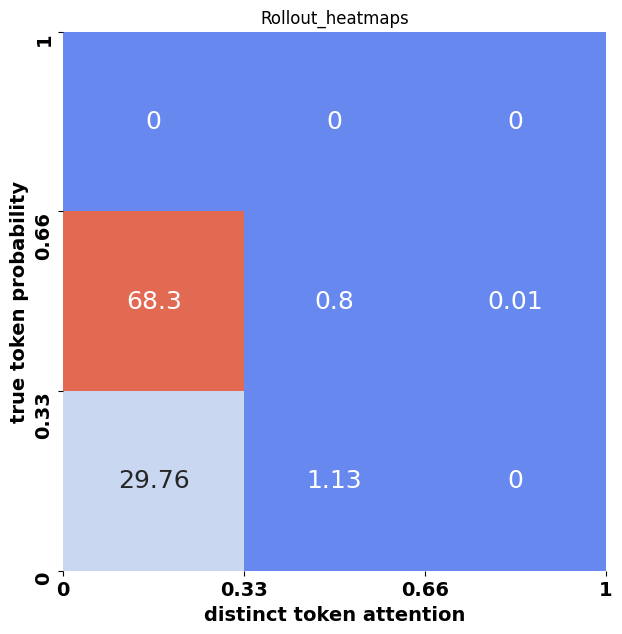

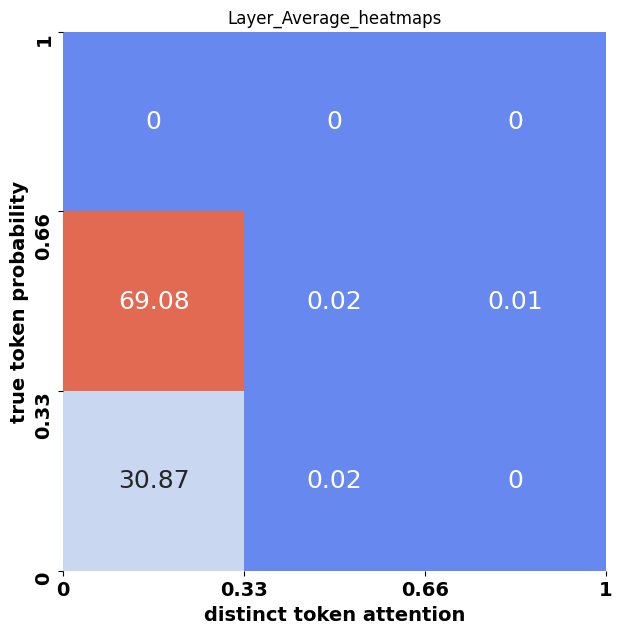

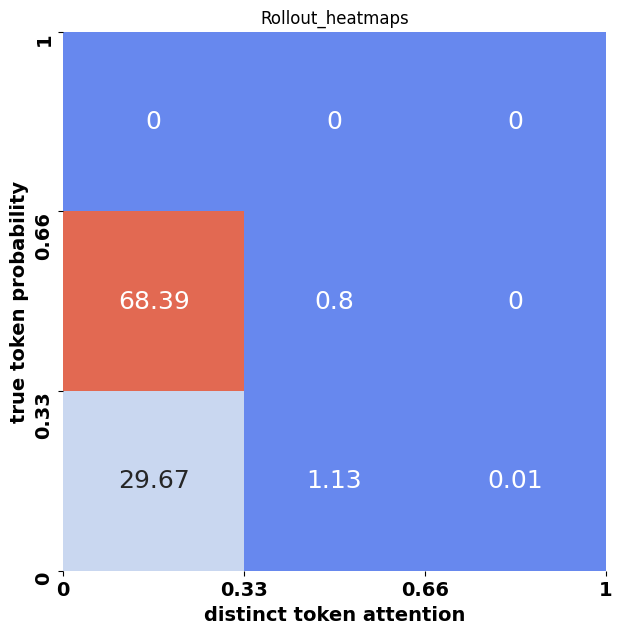

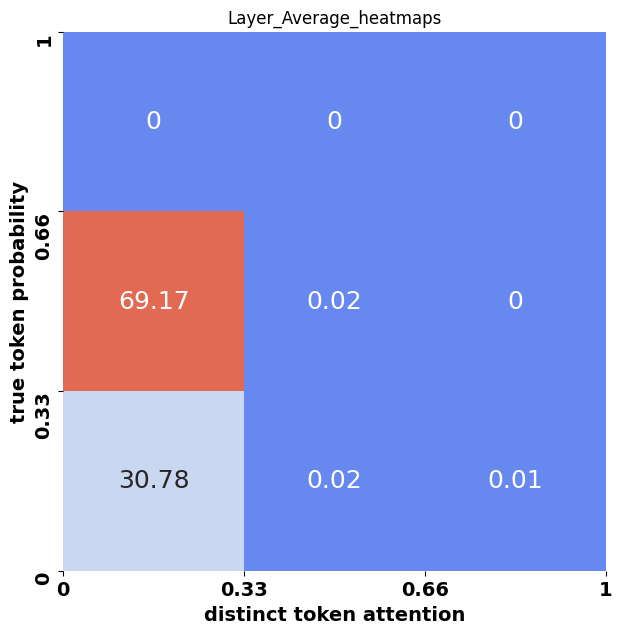

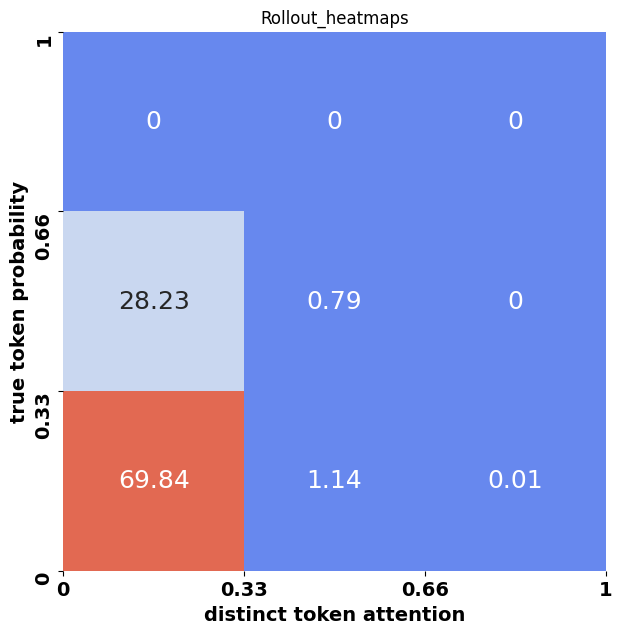

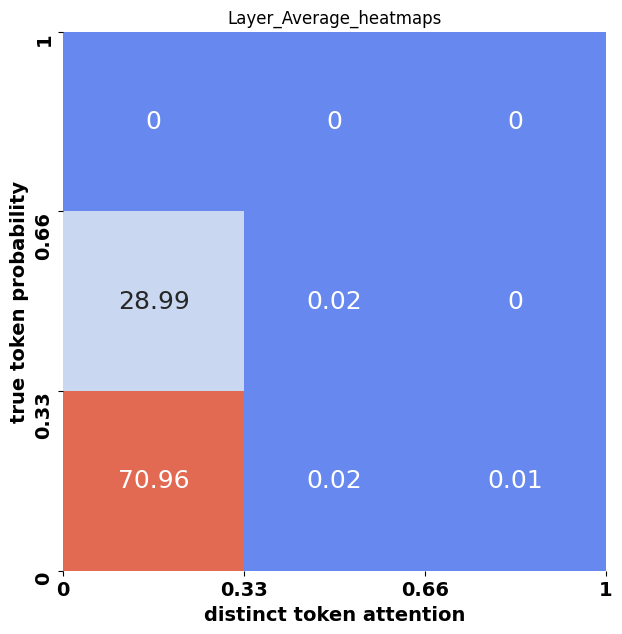

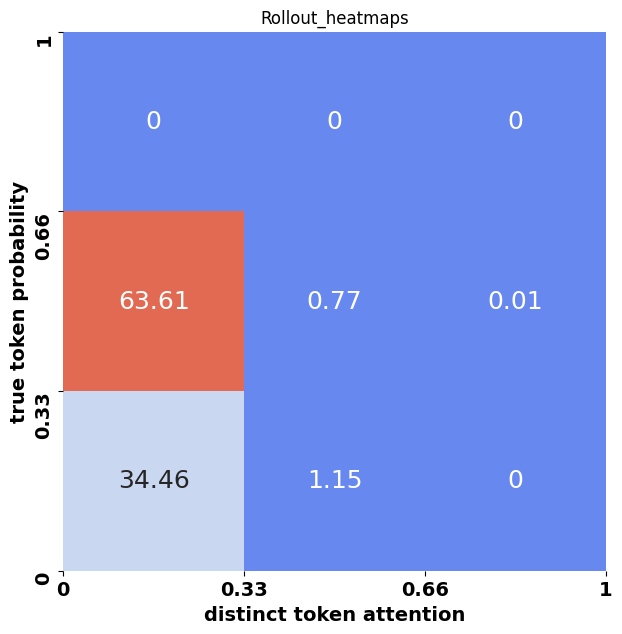

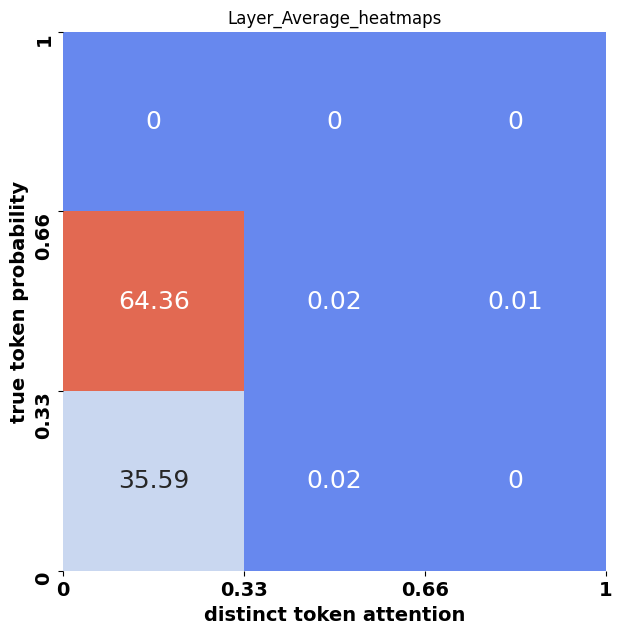

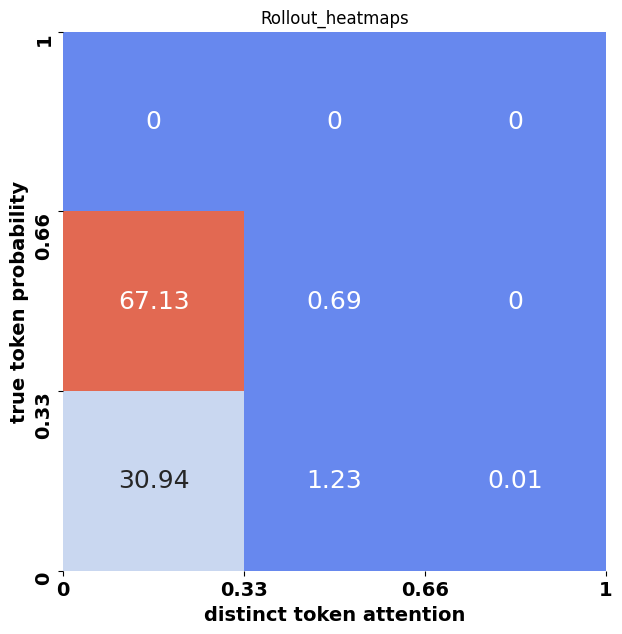

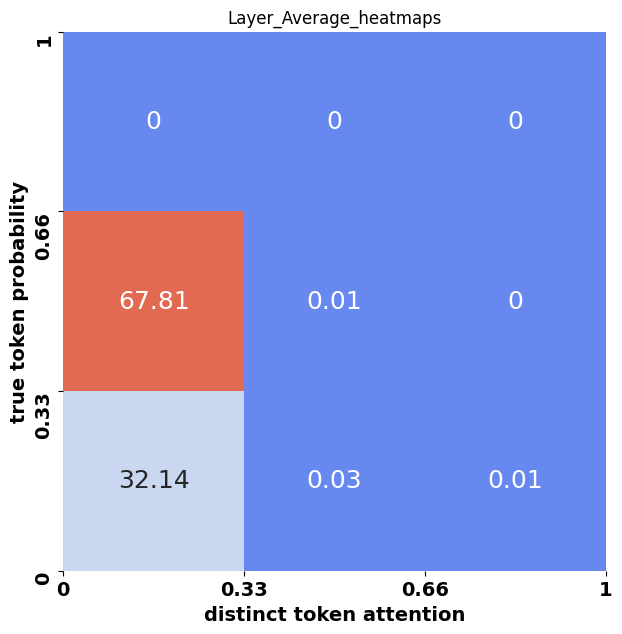

In [64]:
# Main evaluation script
seeds_list = [1234, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"2_layer_Baseline_QK_HX_{nseed}.pt"

    print(f"Initializing baseline model instance...{nseed}")

    baseline_cfg = Config(debug=False, d_model=32, n_heads=4, d_head=8,
                       d_mlp=128, n_layers=2, n_ctx=96,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Baseline model loaded.")

    # Evaluation
    n_samples = 15000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    Prediction_Scores = []

    sample_count = 0

    with torch.no_grad():
        for batch in tqdm.tqdm(train_dataloader):
            if sample_count >= n_samples:
                break

            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            batch_size = inputs.size(0)

            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break

                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]

                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)

                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]

                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()

                output_cls_probs = probs[0,sample_label].item()

                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue

                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)

                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale, k_percent=5, device=device
                )

                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                Prediction_Scores.append(output_cls_probs)

                sample_count += 1


    plot_heatmaps(Attn_Scores_Rollout, Prediction_Scores,"Rollout_heatmaps")
    plot_heatmaps(Attn_Scores_LayerAvg, Prediction_Scores,"Layer_Average_heatmaps")

    # Print results
    print(f"Baseline Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

In [65]:
tqdm

<module 'tqdm.auto' from '/usr/local/lib/python3.12/dist-packages/tqdm/auto.py'>

Initializing baseline model instance...1234
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9771071800208116 0.022892819979188347 0.0
prediction 0.3085327783558793 0.6914672216441207 0.0
attention 0.9994797086368367 0.0005202913631633715 0.0
prediction 0.3085327783558793 0.6914672216441207 0.0
Baseline Train Results...1234
Rollout:           0.0737
Layer-Avg:         0.0365
Max-Pooling:       0.0366
Comprehensiveness: 0.0002 (higher = better)
Sufficiency:       -0.0010 (lower = better)
Initializing baseline model instance...1235
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9771071800208116 0.022892819979188347 0.0
prediction 0.3085327783558793 0.6914672216441207 0.0
attention 0.9994797086368367 0.0005202913631633715 0.0
prediction 0.3085327783558793 0.6914672216441207 0.0
Baseline Train Results...1235
Rollout:           0.0737
Layer-Avg:         0.0366
Max-Pooling:       0.0366
Comprehensiveness: 0.0003 (higher = better)
Sufficiency:       -0.0073 (lower = better)
Initializing baseline model instance...1236
Baseline model loaded.


...

attention 0.9771071800208116 0.022892819979188347 0.0
prediction 0.7101977107180021 0.2898022892819979 0.0
attention 0.9994797086368367 0.0005202913631633715 0.0
prediction 0.7101977107180021 0.2898022892819979 0.0
Baseline Train Results...1236
Rollout:           0.0737
Layer-Avg:         0.0365
Max-Pooling:       0.0366
Comprehensiveness: 0.0004 (higher = better)
Sufficiency:       0.0019 (lower = better)
Initializing baseline model instance...1237
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9771071800208116 0.022892819979188347 0.0
prediction 0.37460978147762747 0.6253902185223725 0.0
attention 0.9994797086368367 0.0005202913631633715 0.0
prediction 0.37460978147762747 0.6253902185223725 0.0
Baseline Train Results...1237
Rollout:           0.0737
Layer-Avg:         0.0366
Max-Pooling:       0.0366
Comprehensiveness: 0.0001 (higher = better)
Sufficiency:       -0.0010 (lower = better)
Initializing baseline model instance...1238
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9771071800208116 0.022892819979188347 0.0
prediction 0.3189386056191467 0.6810613943808532 0.0
attention 0.9994797086368367 0.0005202913631633715 0.0
prediction 0.3189386056191467 0.6810613943808532 0.0
Baseline Train Results...1238
Rollout:           0.0737
Layer-Avg:         0.0366
Max-Pooling:       0.0366
Comprehensiveness: -0.0004 (higher = better)
Sufficiency:       0.0224 (lower = better)


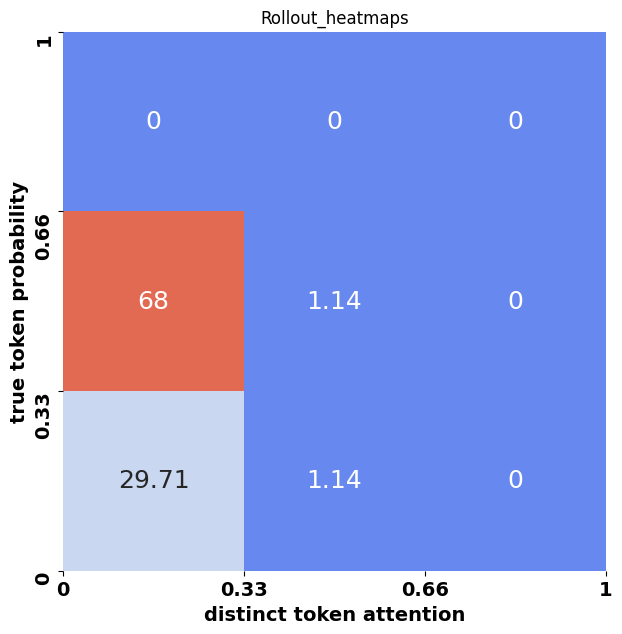

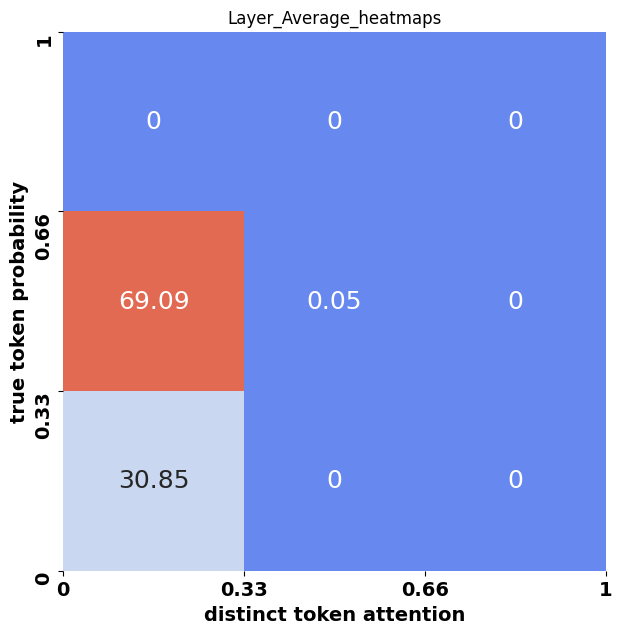

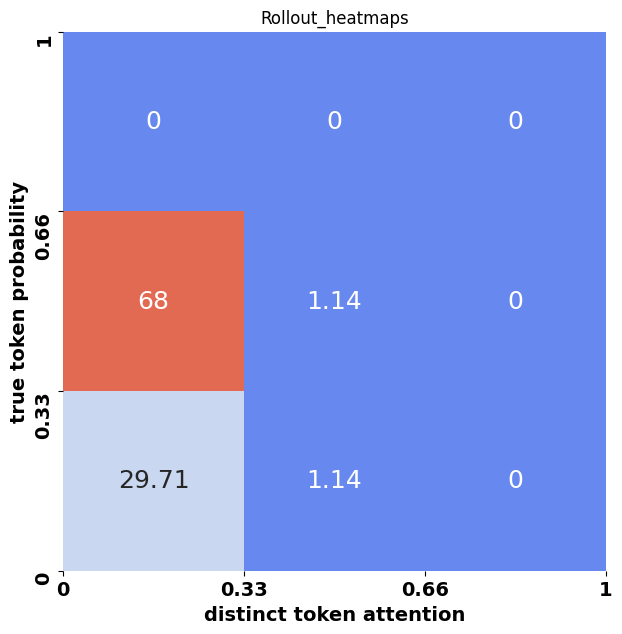

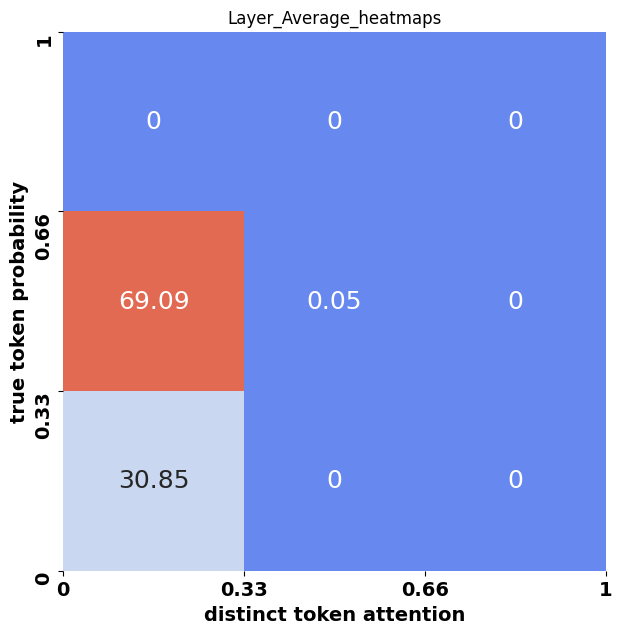

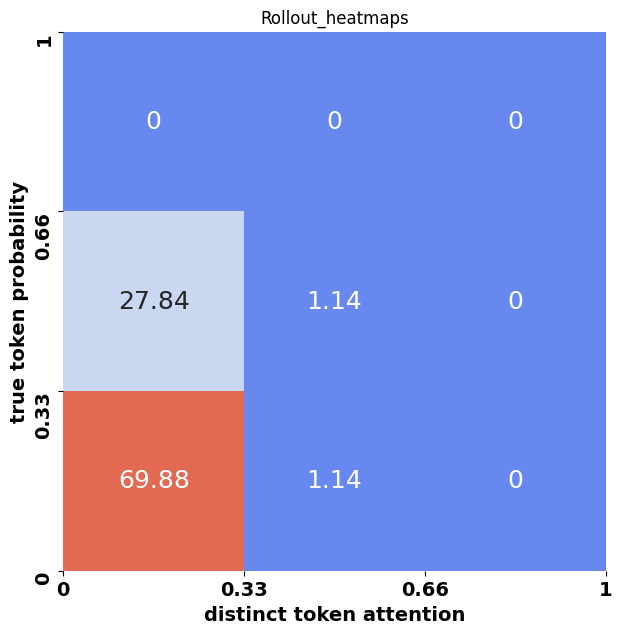

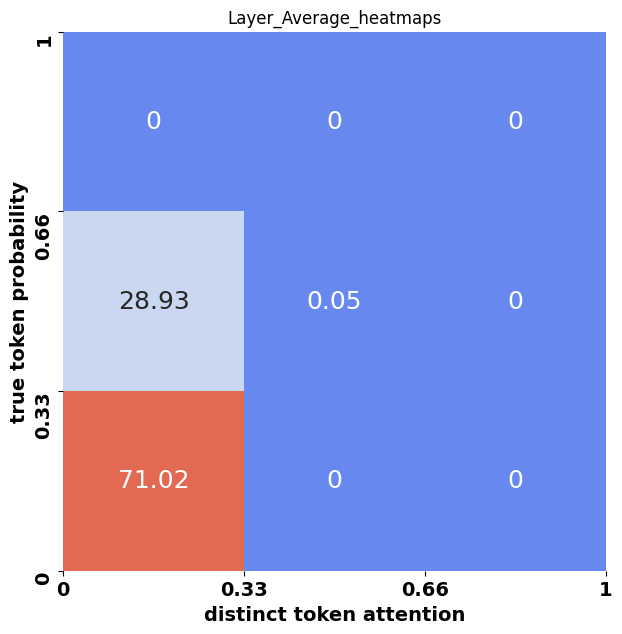

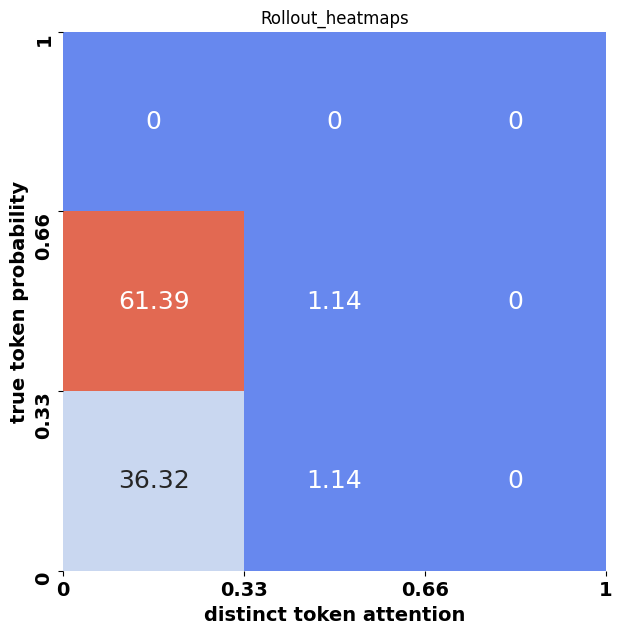

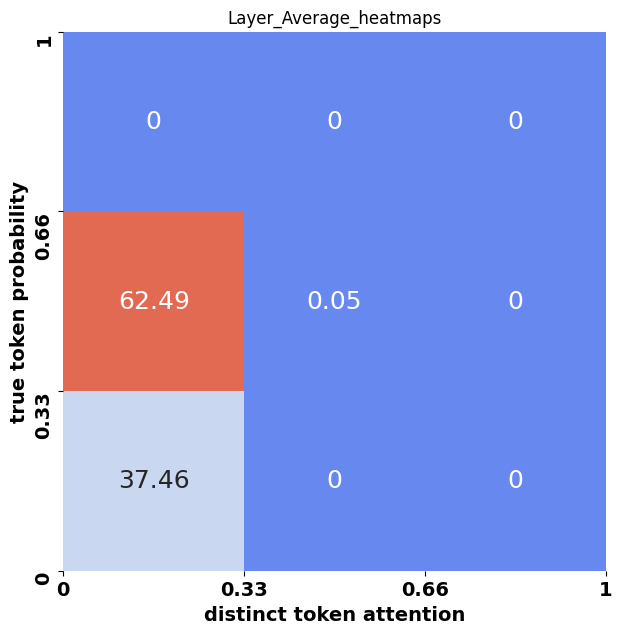

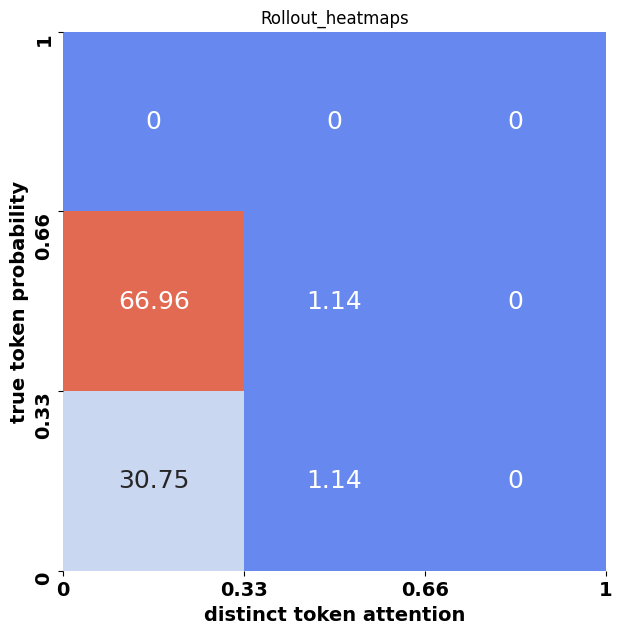

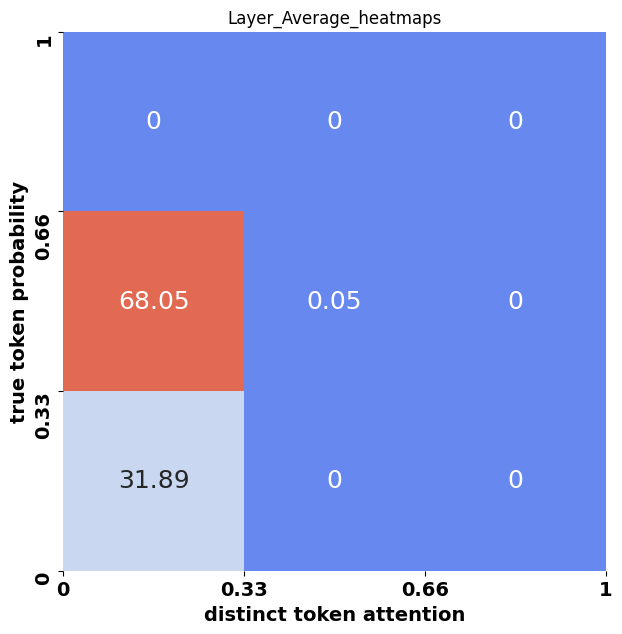

In [66]:
# Main evaluation script
seeds_list = [1234, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"2_layer_Baseline_QK_HX_{nseed}.pt"

    print(f"Initializing baseline model instance...{nseed}")

    baseline_cfg = Config(debug=False, d_model=32, n_heads=4, d_head=8,
                       d_mlp=128, n_layers=2, n_ctx=96,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Baseline model loaded.")

    # Evaluation
    n_samples = 5000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    Prediction_Scores = []

    sample_count = 0

    with torch.no_grad():
        for batch in tqdm.tqdm(validation_dataloader):
            if sample_count >= n_samples:
                break

            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            batch_size = inputs.size(0)

            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break

                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]

                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)

                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]

                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()

                output_cls_probs = probs[0,sample_label].item()

                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue

                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)

                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale, k_percent=5, device=device
                )

                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                Prediction_Scores.append(output_cls_probs)

                sample_count += 1


    plot_heatmaps(Attn_Scores_Rollout, Prediction_Scores,"Rollout_heatmaps")
    plot_heatmaps(Attn_Scores_LayerAvg, Prediction_Scores,"Layer_Average_heatmaps")

    # Print results
    print(f"Baseline Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

Initializing baseline model instance...1234
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9786902286902287 0.02130977130977131 0.0
prediction 0.3087318087318087 0.6912681912681913 0.0
attention 0.9994802494802495 0.0005197505197505198 0.0
prediction 0.3087318087318087 0.6912681912681913 0.0
Baseline Train Results...1234
Rollout:           0.0715
Layer-Avg:         0.0355
Max-Pooling:       0.0355
Comprehensiveness: 0.0002 (higher = better)
Sufficiency:       -0.0001 (lower = better)
Initializing baseline model instance...1235
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9786902286902287 0.02130977130977131 0.0
prediction 0.3087318087318087 0.6912681912681913 0.0
attention 0.9994802494802495 0.0005197505197505198 0.0
prediction 0.3087318087318087 0.6912681912681913 0.0
Baseline Train Results...1235
Rollout:           0.0715
Layer-Avg:         0.0355
Max-Pooling:       0.0356
Comprehensiveness: 0.0002 (higher = better)
Sufficiency:       -0.0073 (lower = better)
Initializing baseline model instance...1236
Baseline model loaded.


...

attention 0.9786902286902287 0.02130977130977131 0.0
prediction 0.7115384615384616 0.28846153846153844 0.0
attention 0.9994802494802495 0.0005197505197505198 0.0
prediction 0.7115384615384616 0.28846153846153844 0.0
Baseline Train Results...1236
Rollout:           0.0715
Layer-Avg:         0.0355
Max-Pooling:       0.0355
Comprehensiveness: -0.0000 (higher = better)
Sufficiency:       0.0017 (lower = better)
Initializing baseline model instance...1237
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9786902286902287 0.02130977130977131 0.0
prediction 0.367983367983368 0.632016632016632 0.0
attention 0.9994802494802495 0.0005197505197505198 0.0
prediction 0.367983367983368 0.632016632016632 0.0
Baseline Train Results...1237
Rollout:           0.0715
Layer-Avg:         0.0355
Max-Pooling:       0.0356
Comprehensiveness: -0.0001 (higher = better)
Sufficiency:       -0.0012 (lower = better)
Initializing baseline model instance...1238
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.9786902286902287 0.02130977130977131 0.0
prediction 0.3196465696465696 0.6803534303534303 0.0
attention 0.9994802494802495 0.0005197505197505198 0.0
prediction 0.3196465696465696 0.6803534303534303 0.0
Baseline Train Results...1238
Rollout:           0.0715
Layer-Avg:         0.0355
Max-Pooling:       0.0356
Comprehensiveness: -0.0004 (higher = better)
Sufficiency:       0.0231 (lower = better)


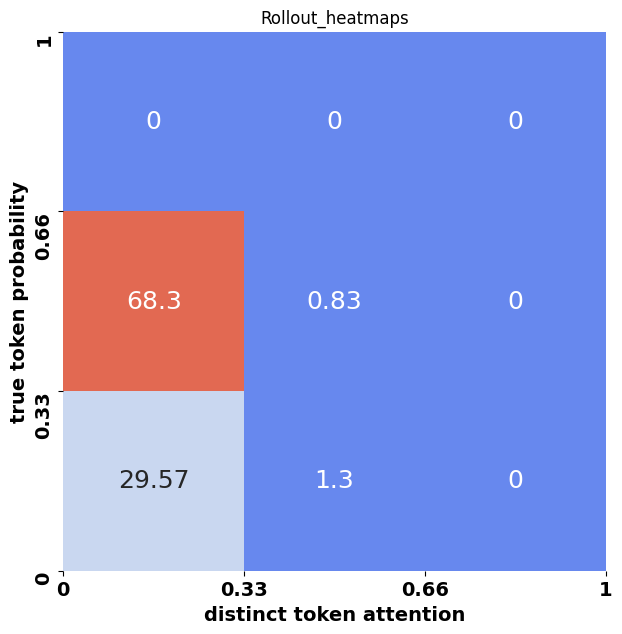

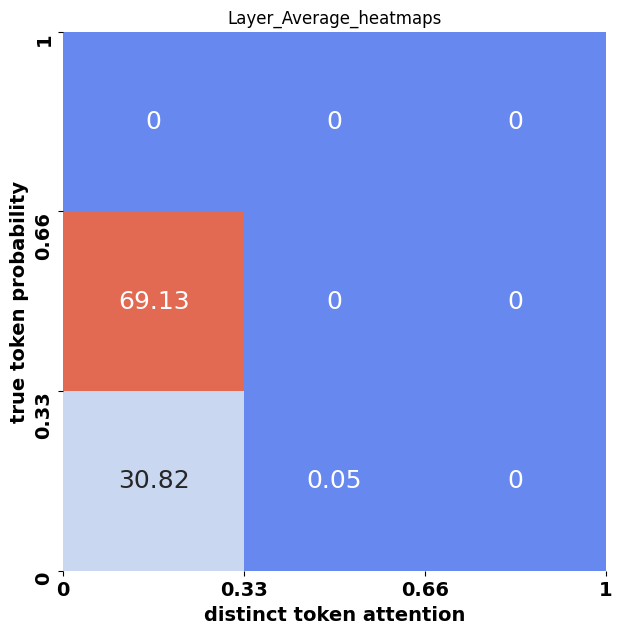

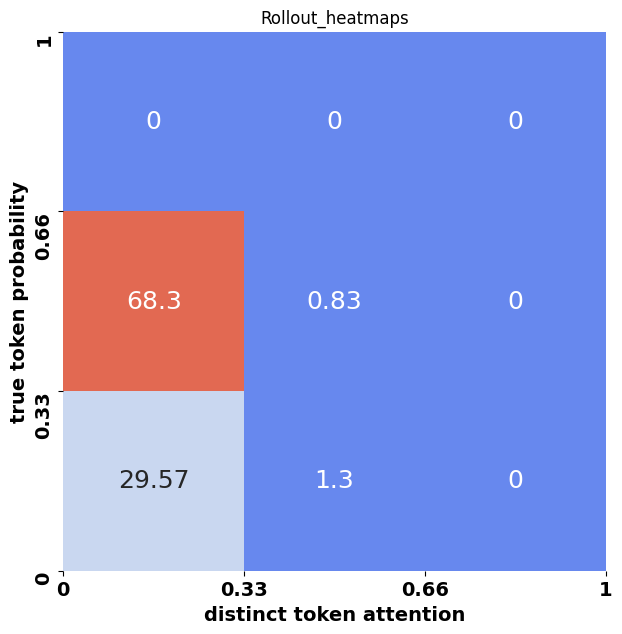

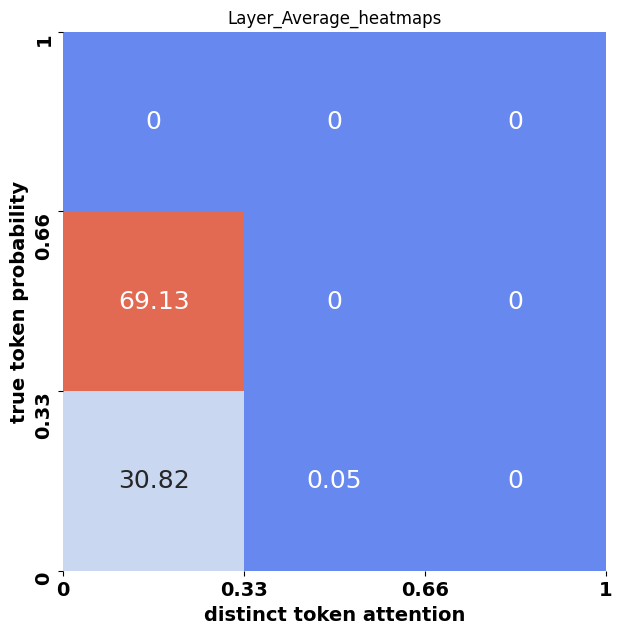

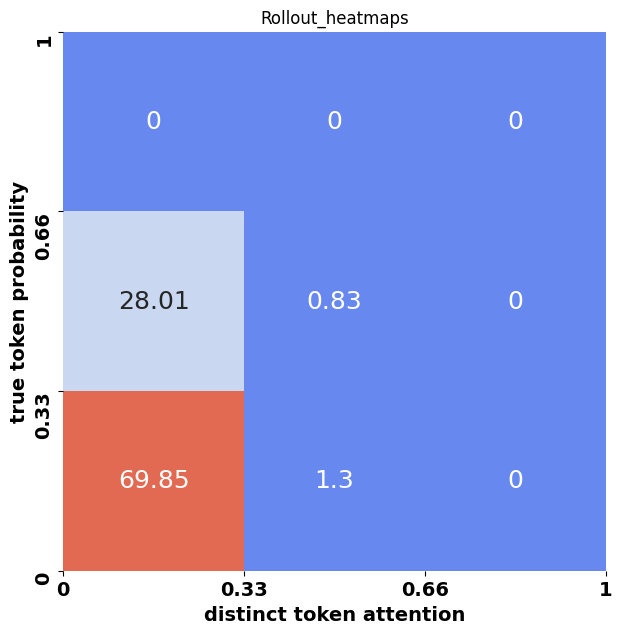

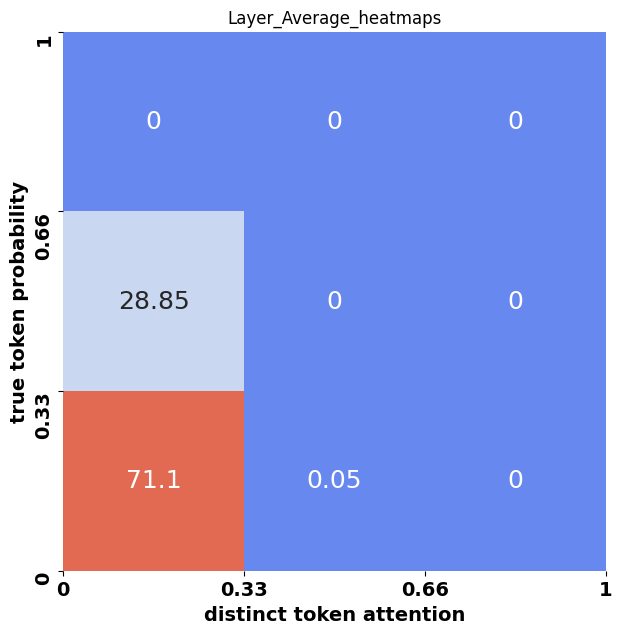

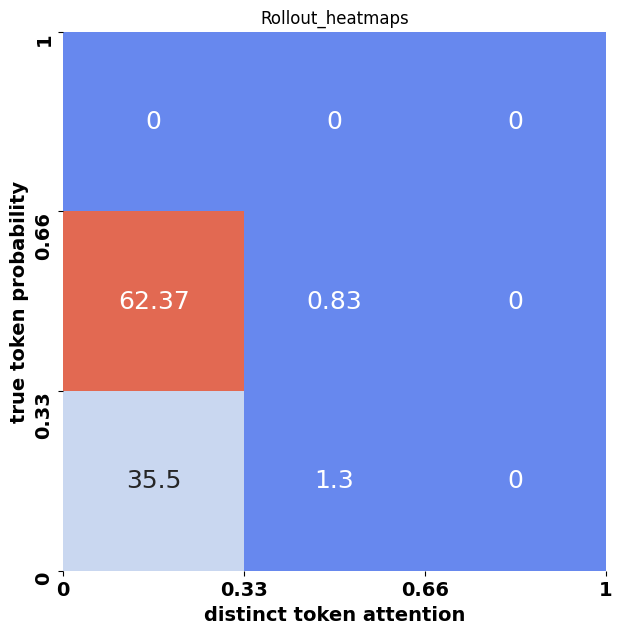

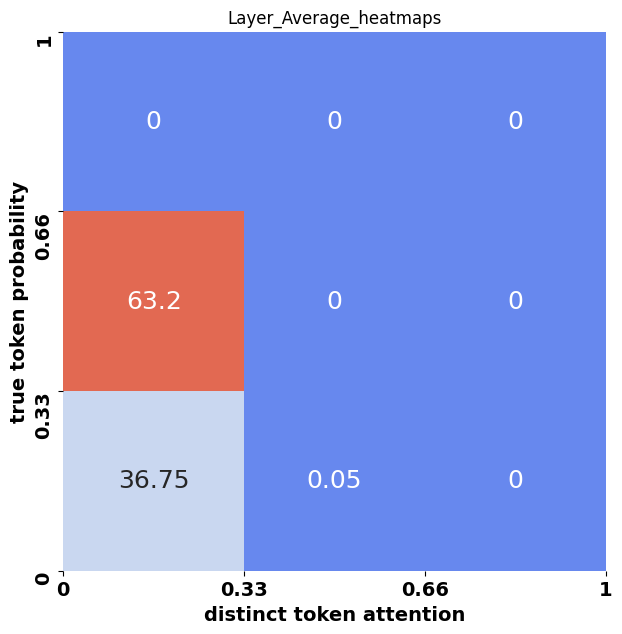

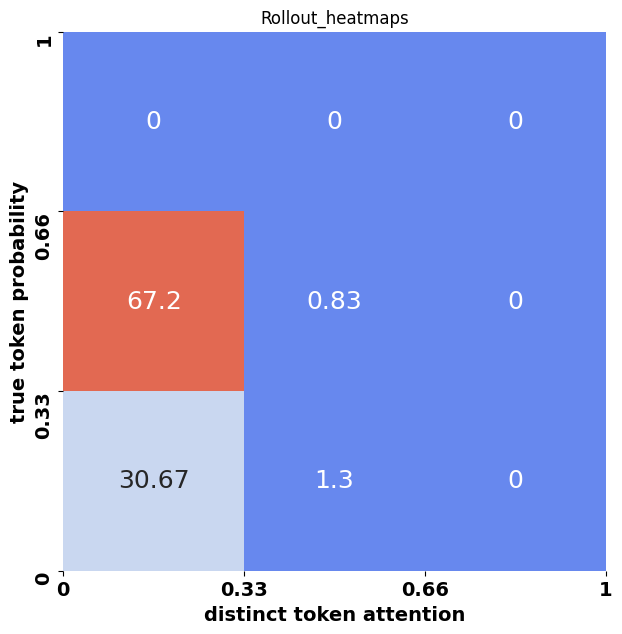

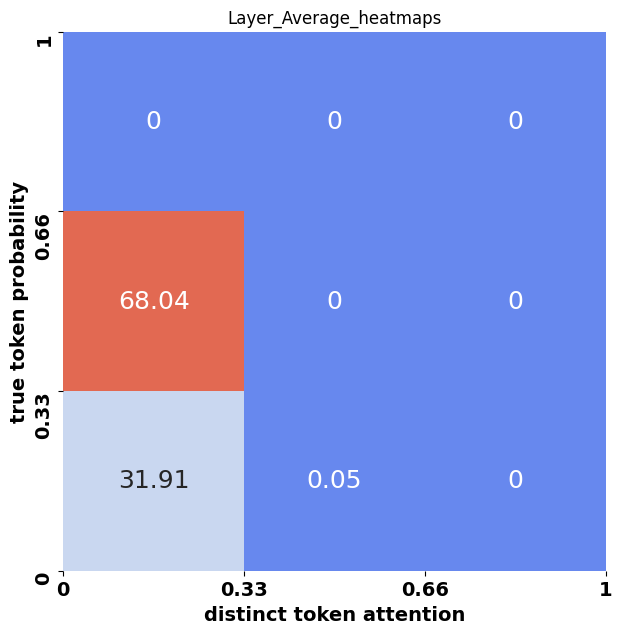

In [67]:
# Main evaluation script
seeds_list = [1234, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"2_layer_Baseline_QK_HX_{nseed}.pt"

    print(f"Initializing baseline model instance...{nseed}")

    baseline_cfg = Config(debug=False, d_model=32, n_heads=4, d_head=8,
                       d_mlp=128, n_layers=2, n_ctx=96,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Baseline model loaded.")

    # Evaluation
    n_samples = 5000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    Prediction_Scores = []

    sample_count = 0

    with torch.no_grad():
        for batch in tqdm.tqdm(test_dataloader):
            if sample_count >= n_samples:
                break

            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            batch_size = inputs.size(0)

            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break

                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]

                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)

                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]

                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()

                output_cls_probs = probs[0,sample_label].item()

                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue

                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)

                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale, k_percent=5, device=device
                )

                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                Prediction_Scores.append(output_cls_probs)

                sample_count += 1


    plot_heatmaps(Attn_Scores_Rollout, Prediction_Scores,"Rollout_heatmaps")
    plot_heatmaps(Attn_Scores_LayerAvg, Prediction_Scores,"Layer_Average_heatmaps")

    # Print results
    print(f"Baseline Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

Initializing baseline model instance...1235
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.8722 0.126 0.0018
prediction 0.2850666666666667 0.5744 0.14053333333333334
attention 0.9288666666666666 0.07106666666666667 6.666666666666667e-05
prediction 0.2850666666666667 0.5744 0.14053333333333334
Baseline Train Results...1235
Rollout:           0.1344
Layer-Avg:         0.1097
Max-Pooling:       0.1674
Comprehensiveness: 0.0820 (higher = better)
Sufficiency:       0.3638 (lower = better)
Initializing baseline model instance...1235
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.8713333333333333 0.12673333333333334 0.0019333333333333333
prediction 0.2850666666666667 0.5747333333333333 0.1402
attention 0.9278 0.07213333333333333 6.666666666666667e-05
prediction 0.2850666666666667 0.5747333333333333 0.1402
Baseline Train Results...1235
Rollout:           0.1345
Layer-Avg:         0.1101
Max-Pooling:       0.1677
Comprehensiveness: 0.0818 (higher = better)
Sufficiency:       0.3637 (lower = better)
Initializing baseline model instance...1236
Baseline model loaded.


...

attention 0.8618 0.12986666666666666 0.008333333333333333
prediction 0.47873333333333334 0.23053333333333334 0.29073333333333334
attention 0.7740666666666667 0.22446666666666668 0.0014666666666666667
prediction 0.47873333333333334 0.23053333333333334 0.29073333333333334
Baseline Train Results...1236
Rollout:           0.1254
Layer-Avg:         0.1695
Max-Pooling:       0.2979
Comprehensiveness: 0.0498 (higher = better)
Sufficiency:       0.4121 (lower = better)
Initializing baseline model instance...1237
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.8675333333333334 0.1244 0.008066666666666666
prediction 0.44006666666666666 0.28073333333333333 0.2792
attention 0.6808666666666666 0.292 0.027133333333333332
prediction 0.44006666666666666 0.28073333333333333 0.2792
Baseline Train Results...1237
Rollout:           0.1174
Layer-Avg:         0.2057
Max-Pooling:       0.3196
Comprehensiveness: 0.0452 (higher = better)
Sufficiency:       0.3997 (lower = better)
Initializing baseline model instance...1238
Baseline model loaded.


  0%|          | 0/481 [00:00<?, ?it/s]

attention 0.8560666666666666 0.13566666666666666 0.008266666666666667
prediction 0.44306666666666666 0.3144 0.24253333333333332
attention 0.7316 0.2677333333333333 0.0006666666666666666
prediction 0.44306666666666666 0.3144 0.24253333333333332
Baseline Train Results...1238
Rollout:           0.1288
Layer-Avg:         0.1836
Max-Pooling:       0.3425
Comprehensiveness: 0.0362 (higher = better)
Sufficiency:       0.3987 (lower = better)


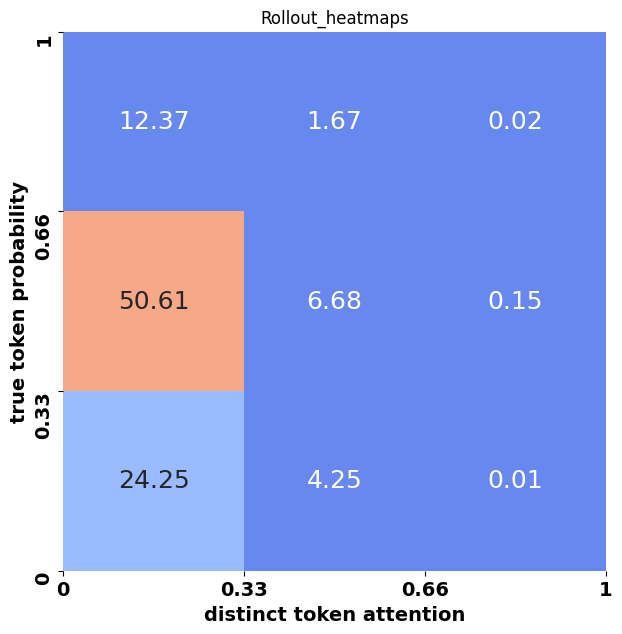

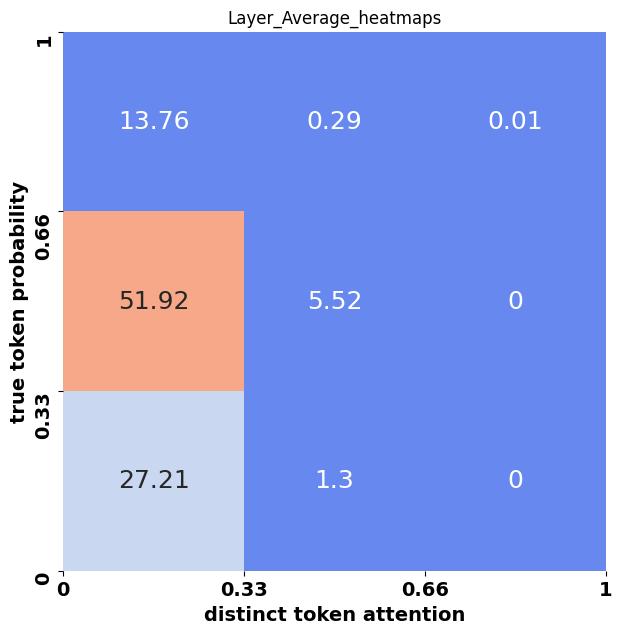

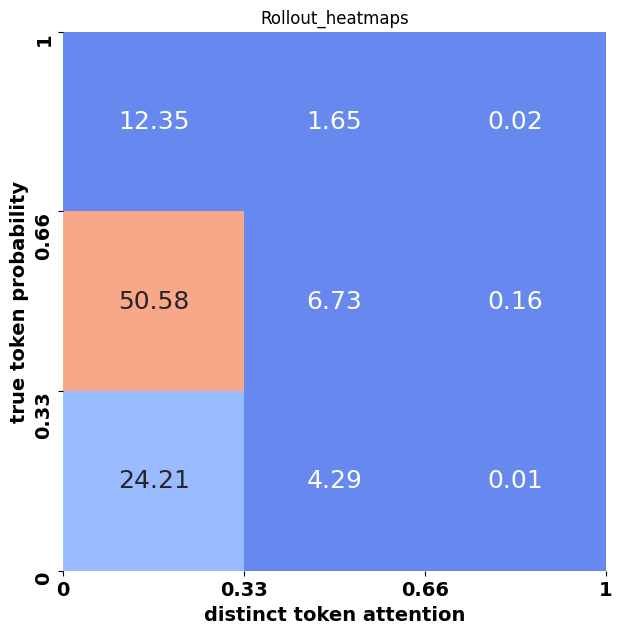

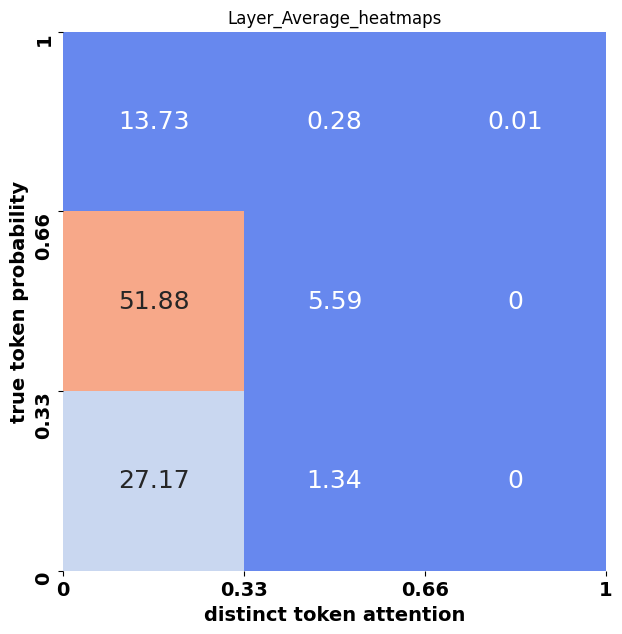

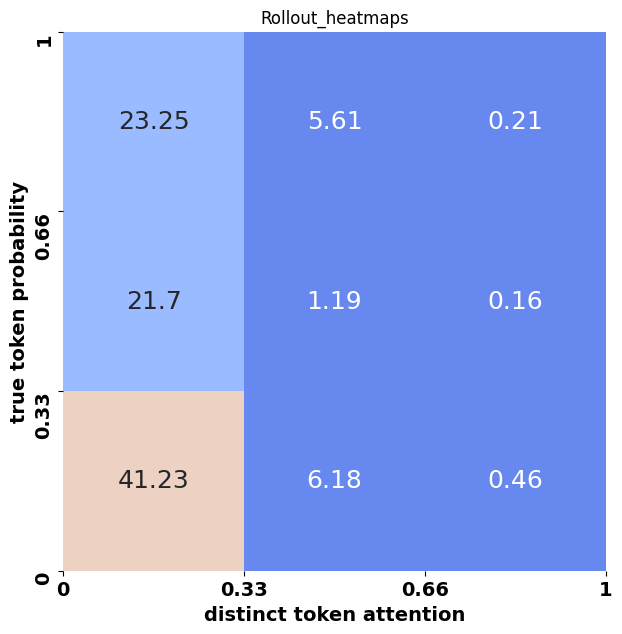

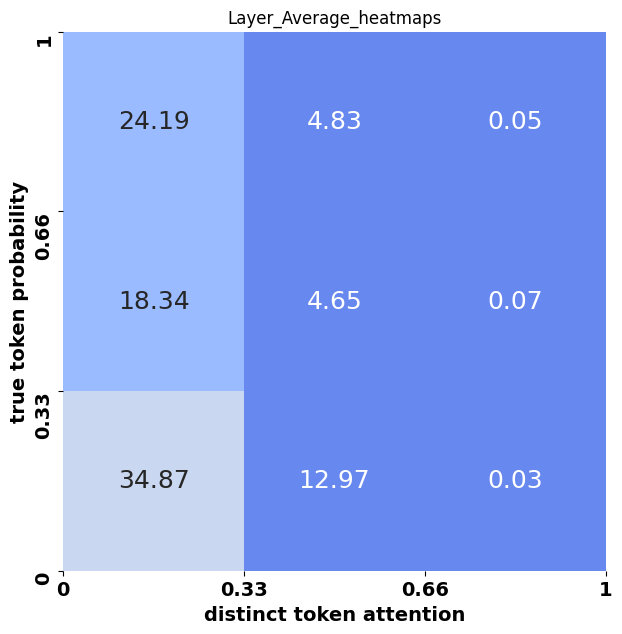

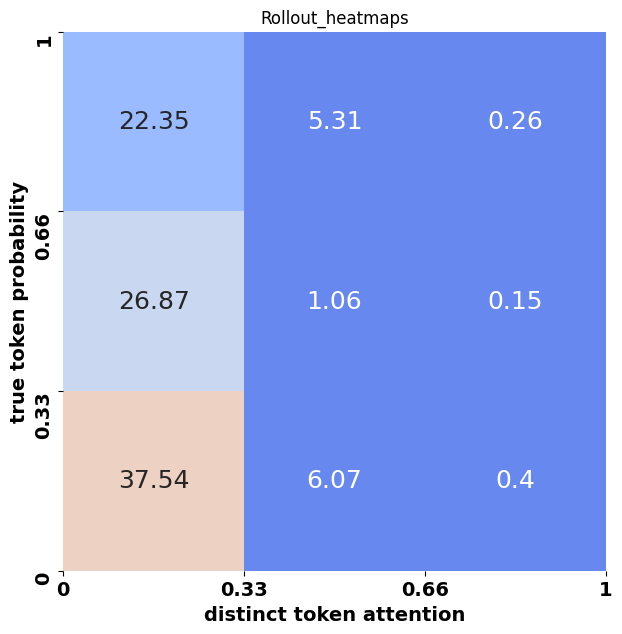

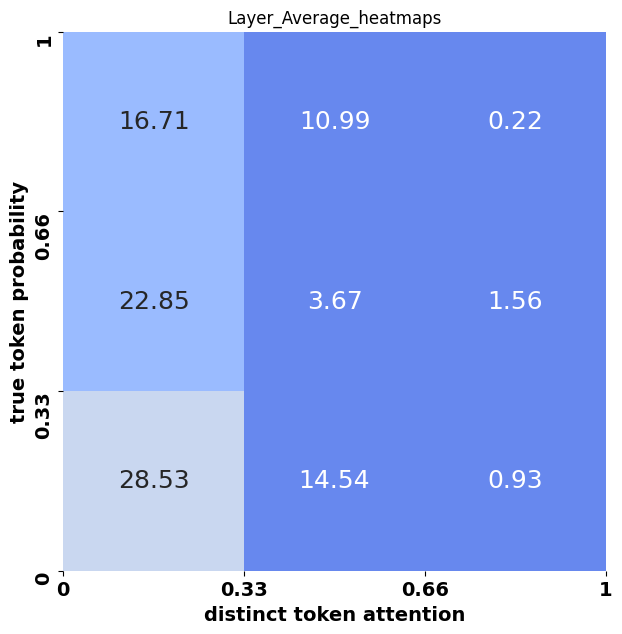

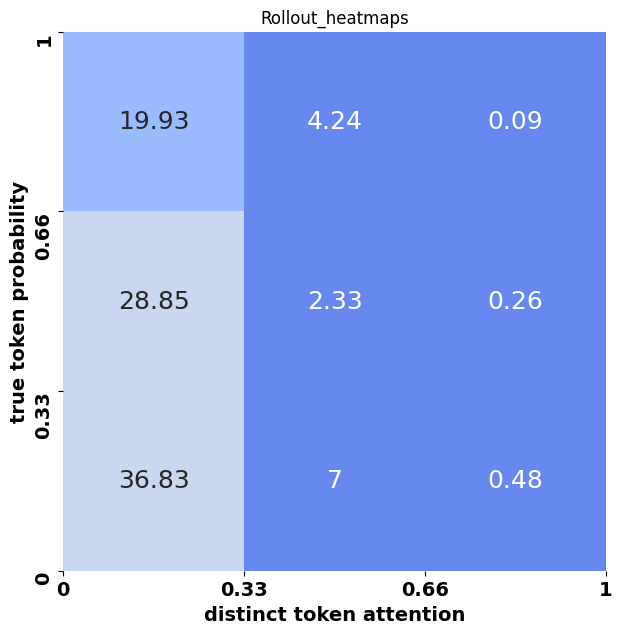

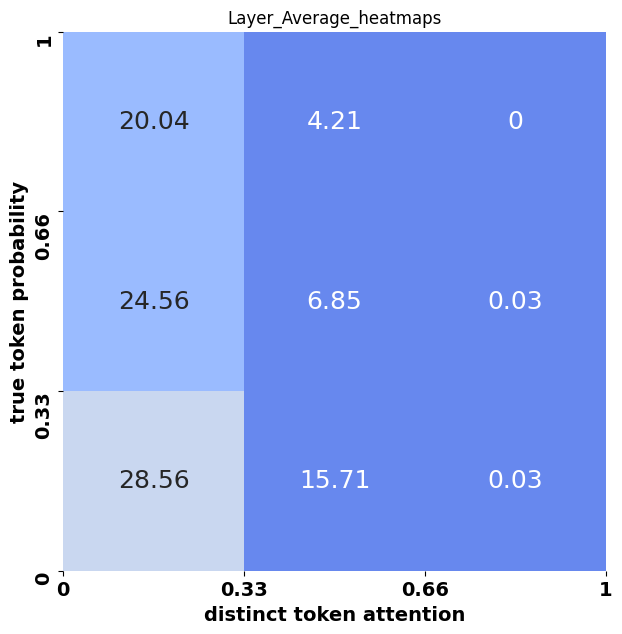

In [68]:
# Main evaluation script
seeds_list = [1235, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"2_layer_Faster_QK_HX_{nseed}.pt"

    print(f"Initializing baseline model instance...{nseed}")

    baseline_cfg = Config(debug=False, d_model=32, n_heads=4, d_head=8,
                       d_mlp=128, n_layers=2, n_ctx=96,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Baseline model loaded.")

    # Evaluation
    n_samples = 15000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    Prediction_Scores = []

    sample_count = 0

    with torch.no_grad():
        for batch in tqdm.tqdm(train_dataloader):
            if sample_count >= n_samples:
                break

            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            batch_size = inputs.size(0)

            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break

                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]

                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)

                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]

                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()

                output_cls_probs = probs[0,sample_label].item()

                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue

                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)

                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale, k_percent=5, device=device
                )

                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                Prediction_Scores.append(output_cls_probs)

                sample_count += 1


    plot_heatmaps(Attn_Scores_Rollout, Prediction_Scores,"Rollout_heatmaps")
    plot_heatmaps(Attn_Scores_LayerAvg, Prediction_Scores,"Layer_Average_heatmaps")

    # Print results
    print(f"Baseline Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

Initializing baseline model instance...1235
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.8850156087408949 0.11290322580645161 0.002081165452653486
prediction 0.4094693028095734 0.4916753381893861 0.09885535900104059
attention 0.9308012486992716 0.0691987513007284 0.0
prediction 0.4094693028095734 0.4916753381893861 0.09885535900104059
Baseline Train Results...1235
Rollout:           0.1335
Layer-Avg:         0.1079
Max-Pooling:       0.1651
Comprehensiveness: 0.0816 (higher = better)
Sufficiency:       0.3875 (lower = better)
Initializing baseline model instance...1235
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.8850156087408949 0.11290322580645161 0.002081165452653486
prediction 0.4094693028095734 0.4916753381893861 0.09885535900104059
attention 0.9308012486992716 0.0691987513007284 0.0
prediction 0.4094693028095734 0.4916753381893861 0.09885535900104059
Baseline Train Results...1235
Rollout:           0.1335
Layer-Avg:         0.1079
Max-Pooling:       0.1651
Comprehensiveness: 0.0816 (higher = better)
Sufficiency:       0.3875 (lower = better)
Initializing baseline model instance...1236
Baseline model loaded.


...

attention 0.8668054110301769 0.1259105098855359 0.007284079084287201
prediction 0.5525494276795005 0.18210197710718 0.26534859521331944
attention 0.7887617065556711 0.20967741935483872 0.0015608740894901144
prediction 0.5525494276795005 0.18210197710718 0.26534859521331944
Baseline Train Results...1236
Rollout:           0.1254
Layer-Avg:         0.1656
Max-Pooling:       0.2908
Comprehensiveness: 0.0457 (higher = better)
Sufficiency:       0.4159 (lower = better)
Initializing baseline model instance...1237
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.868366285119667 0.1222684703433923 0.009365244536940686
prediction 0.5317377731529657 0.23829344432882413 0.2299687825182102
attention 0.6987513007284079 0.277315296566077 0.023933402705515087
prediction 0.5317377731529657 0.23829344432882413 0.2299687825182102
Baseline Train Results...1237
Rollout:           0.1176
Layer-Avg:         0.2003
Max-Pooling:       0.3122
Comprehensiveness: 0.0427 (higher = better)
Sufficiency:       0.4106 (lower = better)
Initializing baseline model instance...1238
Baseline model loaded.


  0%|          | 0/61 [00:00<?, ?it/s]

attention 0.8485952133194589 0.14516129032258066 0.006243496357960458
prediction 0.5166493236212278 0.277315296566077 0.2060353798126951
attention 0.7382934443288242 0.2611862643080125 0.0005202913631633715
prediction 0.5166493236212278 0.277315296566077 0.2060353798126951
Baseline Train Results...1238
Rollout:           0.1306
Layer-Avg:         0.1802
Max-Pooling:       0.3355
Comprehensiveness: 0.0358 (higher = better)
Sufficiency:       0.4119 (lower = better)


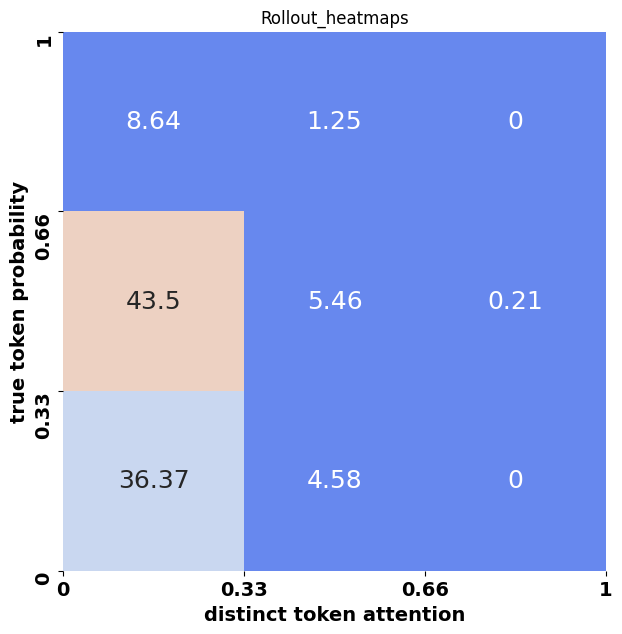

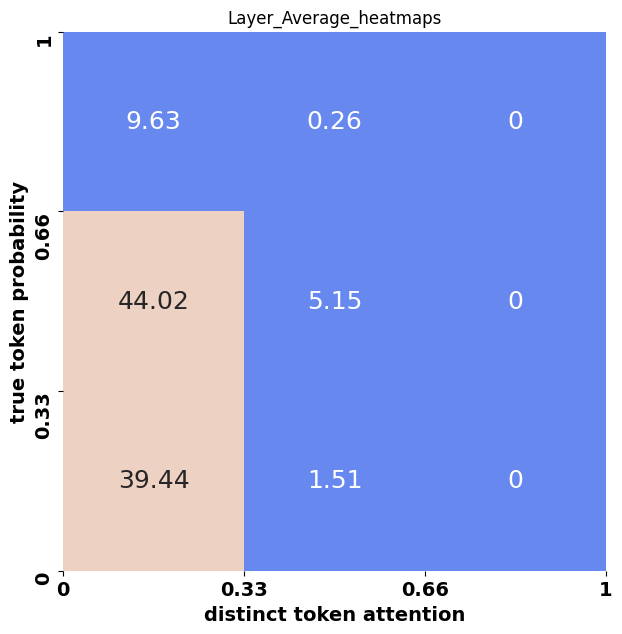

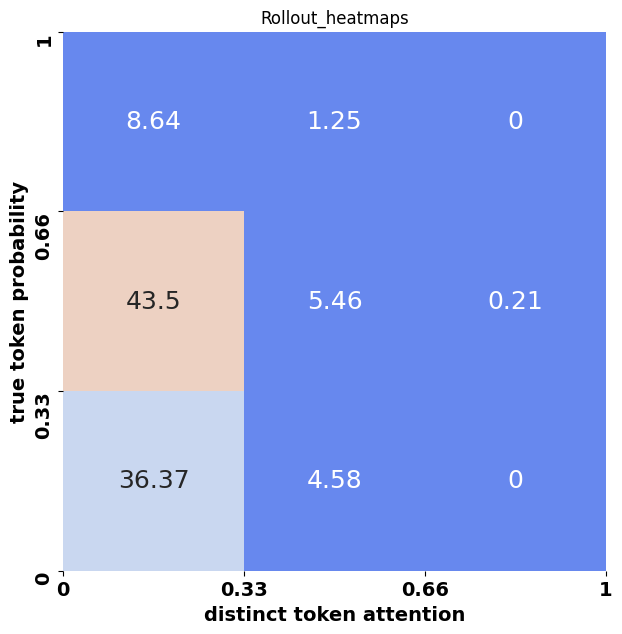

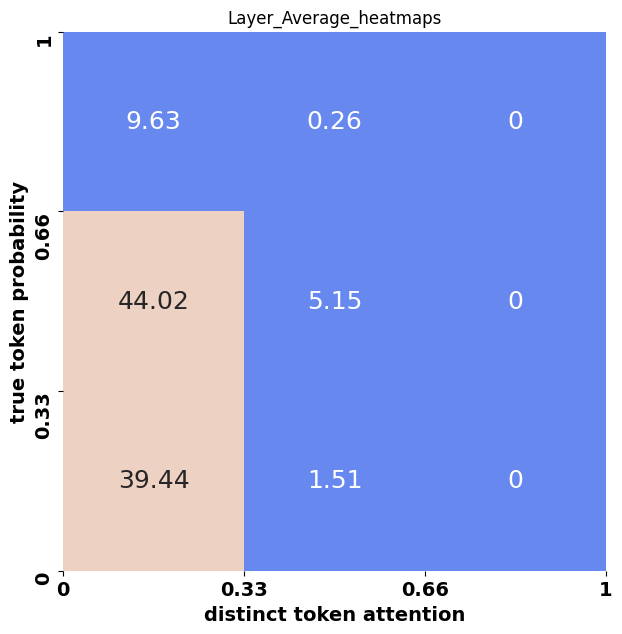

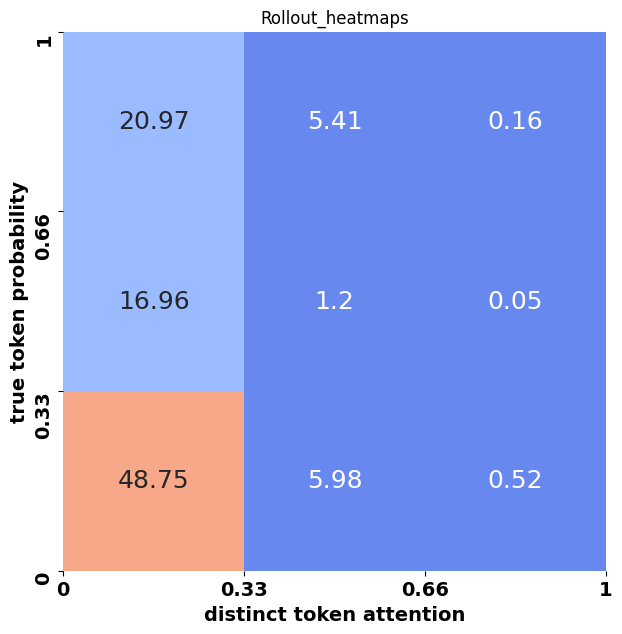

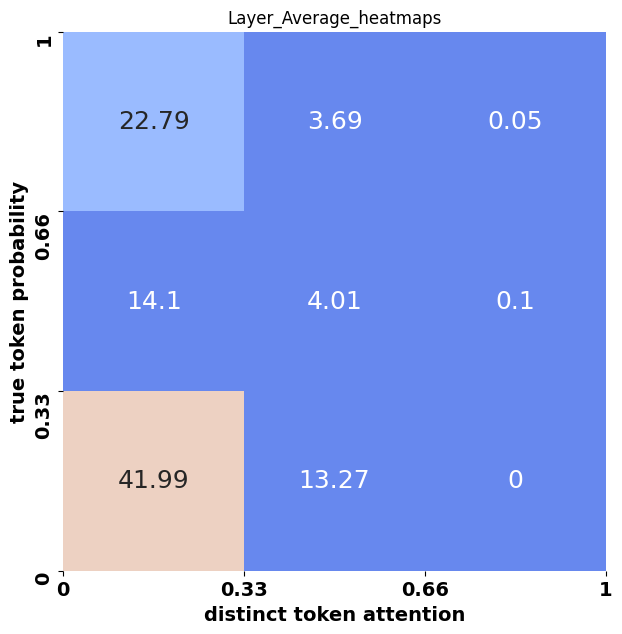

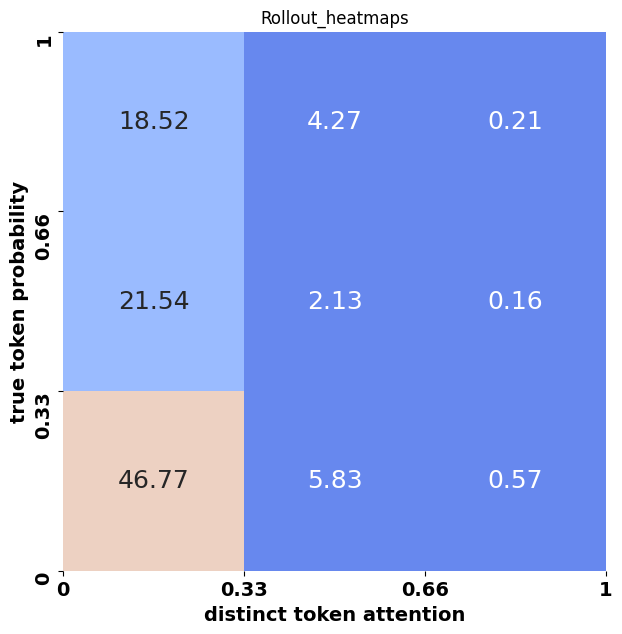

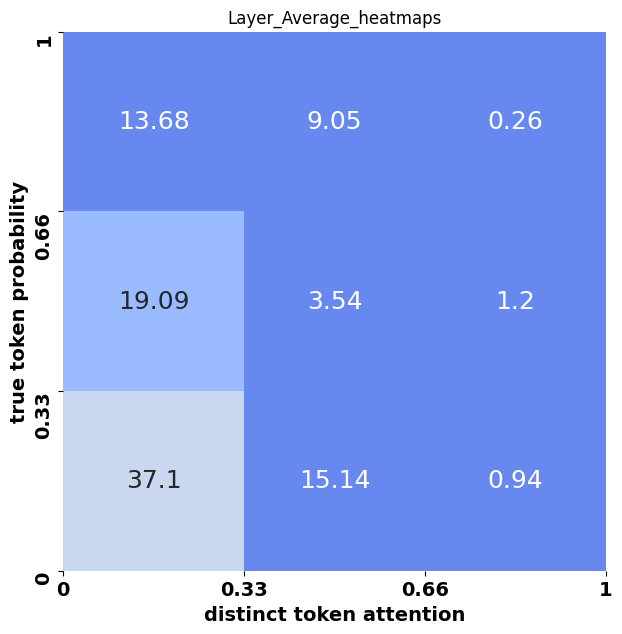

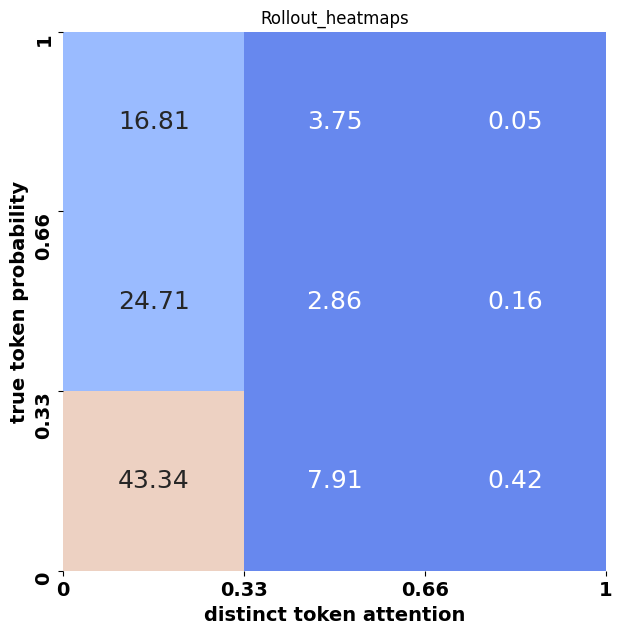

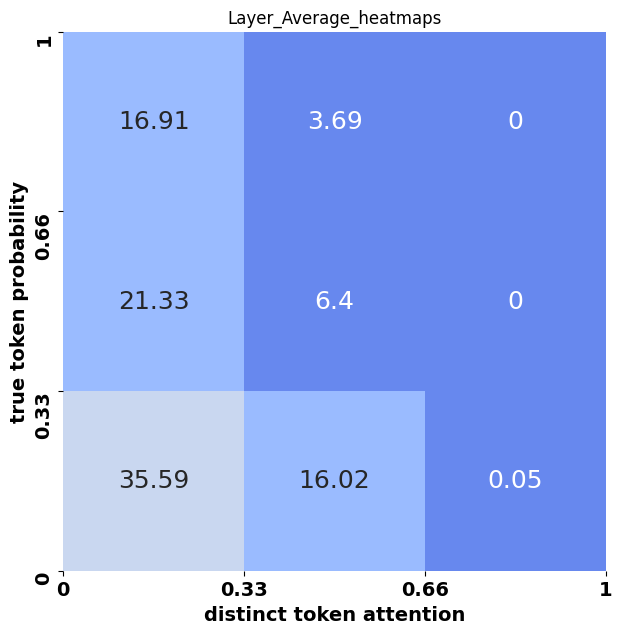

In [69]:
# Main evaluation script
seeds_list = [1235, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"2_layer_Faster_QK_HX_{nseed}.pt"

    print(f"Initializing baseline model instance...{nseed}")

    baseline_cfg = Config(debug=False, d_model=32, n_heads=4, d_head=8,
                       d_mlp=128, n_layers=2, n_ctx=96,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Baseline model loaded.")

    # Evaluation
    n_samples = 15000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    Prediction_Scores = []

    sample_count = 0

    with torch.no_grad():
        for batch in tqdm.tqdm(validation_dataloader):
            if sample_count >= n_samples:
                break

            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            batch_size = inputs.size(0)

            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break

                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]

                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)

                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]

                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()

                output_cls_probs = probs[0,sample_label].item()

                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue

                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)

                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale, k_percent=5, device=device
                )

                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                Prediction_Scores.append(output_cls_probs)

                sample_count += 1


    plot_heatmaps(Attn_Scores_Rollout, Prediction_Scores,"Rollout_heatmaps")
    plot_heatmaps(Attn_Scores_LayerAvg, Prediction_Scores,"Layer_Average_heatmaps")

    # Print results
    print(f"Baseline Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

In [70]:
# Main evaluation script
seeds_list = [1235, 1235, 1236, 1237, 1238]

# Load your dataset and model setup here
# val_dataloader = ...

for nseed in seeds_list:
    BASELINE_CKPT = f"2_layer_Faster_QK_HX_{nseed}.pt"

    print(f"Initializing baseline model instance...{nseed}")

    baseline_cfg = Config(debug=False, d_model=64, n_heads=4, d_head=64,
                       d_mlp=256, n_layers=1, n_ctx=256,
                       d_vocab=tokenizer.vocab_size)
    baseline = DemoTransformer(baseline_cfg).cuda()

    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt)
    baseline.eval()
    print("Baseline model loaded.")

    # Evaluation
    n_samples = 15000
    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []
    Prediction_Scores = []

    sample_count = 0

    with torch.no_grad():
        for batch in tqdm.tqdm(test_dataloader):
            if sample_count >= n_samples:
                break

            inputs, rationales, mask, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            batch_size = inputs.size(0)

            # Process each sample in the batch
            for i in range(batch_size):
                if sample_count >= n_samples:
                    break

                # Get single sample
                sample_input = inputs[i:i+1]  # Keep batch dimension
                sample_rationale = rationales[i]
                sample_label = labels[i]

                # Get predictions with attention for this sample
                logits, attention_weights = baseline(sample_input)

                # Convert attention to numpy (extract from batch dimension)
                attention_weights_np = [att[0].cpu().numpy() for att in attention_weights]

                # Get predicted class and probability
                probs = F.softmax(logits, dim=-1)
                predicted_class = logits.argmax(-1).item()
                original_prob = probs[0, predicted_class].item()

                output_cls_probs = probs[0,sample_label].item()

                # Get rationale positions (indices where rationales == 1)
                #rationale_positions = (sample_rationale == 1).nonzero(as_tuple=True)[0].cpu().tolist()
                #if not rationale_positions:
                #    continue

                # Compute attention mass metrics
                rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = \
                    attention_mass_classification(attention_weights_np, sample_rationale, alpha=1)

                # Compute comprehensiveness and sufficiency
                comp, suff = compute_comprehensiveness_sufficiency_classification(
                    baseline, sample_input, predicted_class, original_prob,
                    rollout_attn_probs, sample_rationale, k_percent=5, device=device
                )

                Attn_Scores_Rollout.append(rollout_mass)
                Attn_Scores_LayerAvg.append(layer_avg_mass)
                Attn_Scores_MaxPool.append(max_pool_mass)
                Comprehensiveness_Scores.append(comp)
                Sufficiency_Scores.append(suff)
                Prediction_Scores.append(output_cls_probs)

                sample_count += 1


    plot_heatmaps(Attn_Scores_Rollout, Prediction_Scores,"Rollout_heatmaps")
    plot_heatmaps(Attn_Scores_LayerAvg, Prediction_Scores,"Layer_Average_heatmaps")

    # Print results
    print(f"Baseline Train Results...{nseed}")
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

Initializing baseline model instance...1235


RuntimeError: Error(s) in loading state_dict for DemoTransformer:
	Unexpected key(s) in state_dict: "blocks.1.ln1.w", "blocks.1.ln1.b", "blocks.1.attn.W_Q", "blocks.1.attn.b_Q", "blocks.1.attn.W_K", "blocks.1.attn.b_K", "blocks.1.attn.W_V", "blocks.1.attn.b_V", "blocks.1.attn.W_O", "blocks.1.attn.b_O", "blocks.1.attn.IGNORE", "blocks.1.ln2.w", "blocks.1.ln2.b", "blocks.1.mlp.W_in", "blocks.1.mlp.b_in", "blocks.1.mlp.W_out", "blocks.1.mlp.b_out". 
	size mismatch for embed.W_E: copying a param with shape torch.Size([30522, 32]) from checkpoint, the shape in current model is torch.Size([30522, 64]).
	size mismatch for pos_embed.W_pos: copying a param with shape torch.Size([96, 32]) from checkpoint, the shape in current model is torch.Size([256, 64]).
	size mismatch for blocks.0.ln1.w: copying a param with shape torch.Size([32]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for blocks.0.ln1.b: copying a param with shape torch.Size([32]) from checkpoint, th

In [ ]:
1_layer_Faster_QK_HX_1235